# Cell-cell communication analysis with CellPhoneDB

## Overview

This tutorial is organized around the OmicVerse CellPhoneDB workflow and uses the same `ccc_*` interface family for all downstream visualizations.

This notebook is organized into three visualization families:

1. `ov.pl.ccc_heatmap`
2. `ov.pl.ccc_network_plot`
3. `ov.pl.ccc_stat_plot`

The goal is not to simply list plots, but to make clear:

- which views are best for interaction-level detail
- which are better for pathway-level aggregation
- which are better for network interpretation and prioritization

## Method background

Following the [CellPhoneDB documentation](https://cellphonedb.readthedocs.io/) and the updated [CellPhoneDB v5 Nature Protocols article](https://www.nature.com/articles/s41596-024-01137-1), CellPhoneDB focuses on ligand-receptor-mediated communication and explicitly models multimeric complexes.

The core workflow is:

- prepare a normalized expression matrix and a cell-type annotation table
- compute interaction means for each sender-receiver pair
- permute cell labels to estimate which interaction means are unexpectedly specific
- summarize significant interactions for downstream pathway and network interpretation

This permutation-based design is useful because it separates highly expressed but non-specific signals from interactions that are enriched for particular cell-type pairs.

## Why use the EVT dataset here?

This EVT trophoblast dataset is widely used in CellPhoneDB examples and contains interpretable trophoblast-immune interactions. It is therefore a good teaching dataset for showing how interaction-level tables are converted into higher-level communication views.


In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import omicverse as ov

ov.plot_set(font_path='Arial')

%reload_ext autoreload
%autoreload 2

🔬 Starting plot initialization...
Using already downloaded Arial font from: /var/folders/rv/3jnfbs0d6r7d0c5bfj7ft5k00000gn/T/omicverse_arial.ttf


Matplotlib is building the font cache; this may take a moment.


Registered as: Arial
🧬 Detecting GPU devices…
✅ Apple Silicon MPS detected
    • [MPS] Apple Silicon GPU - Metal Performance Shaders available

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.1.3rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



## 1. Load the EVT dataset

This notebook uses the EVT dataset commonly shown in the official CellPhoneDB tutorials.

The purpose of this step is to:

- prepare the expression matrix
- prepare cell-type annotations
- provide one consistent input object for the CellPhoneDB and `ccc_*` examples


In [2]:
adata = ov.read('data/cpdb/normalised_log_counts.h5ad')
adata = adata[
    adata.obs['cell_labels'].isin(
        [
            'eEVT', 'iEVT', 'EVT_1', 'EVT_2', 'DC',
            'dNK1', 'dNK2', 'dNK3', 'VCT', 'VCT_CCC',
            'VCT_fusing', 'VCT_p', 'GC', 'SCT',
        ]
    )
]
adata


View of AnnData object with n_obs × n_vars = 1065 × 30800
    obs: 'n_genes', 'n_counts', 'cell_labels'
    var: 'gene_ids', 'feature_types'
    uns: 'neighbors_scVI_n_latent_14_sample_n_layers_3', 'neighbors_scVI_n_latent_20_sample_n_layers_3', 'umap'
    obsm: 'X_scVI_n_latent_14_sample_n_layers_3', 'X_scVI_n_latent_20_sample_n_layers_3', 'X_umap', 'X_umap_scVI_n_latent_14_sample_n_layers_3', 'X_umap_scVI_n_latent_20_sample_n_layers_3'
    obsp: 'neighbors_scVI_n_latent_14_sample_n_layers_3_connectivities', 'neighbors_scVI_n_latent_14_sample_n_layers_3_distances', 'neighbors_scVI_n_latent_20_sample_n_layers_3_connectivities', 'neighbors_scVI_n_latent_20_sample_n_layers_3_distances'

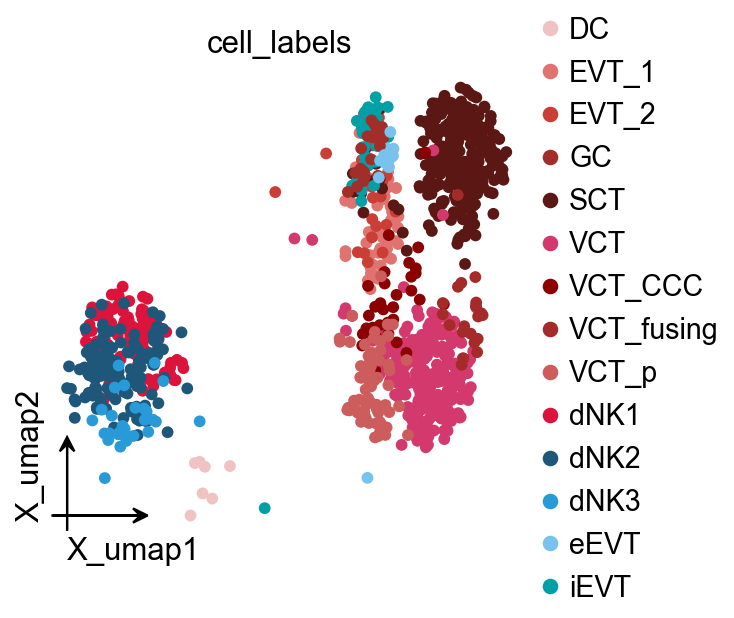

In [3]:
ov.pl.embedding(
    adata,
    basis='X_umap',
    color='cell_labels',
    frameon='small',
    palette=ov.pl.red_color + ov.pl.blue_color + ov.pl.green_color + ov.pl.orange_color + ov.pl.purple_color,
)


## 2. Run CellPhoneDB

`ov.single.run_cellphonedb_v5(...)` returns:

- `cpdb_results`: the raw result tables
- `adata_cpdb`: the standardized communication `AnnData`

It also writes the result back into `adata.uns['cpdb_results']`, so downstream `ccc_*` plots can consume the original `adata` directly.


In [4]:
cpdb_results, adata_cpdb = ov.single.run_cellphonedb_v5(
    adata,
    cpdb_file_path='./cellphonedb.zip',
    celltype_key='cell_labels',
    min_cell_fraction=0.005,
    min_genes=200,
    min_cells=3,
    iterations=1000,
    threshold=0.1,
    pvalue=0.05,
    threads=10,
    output_dir='./cpdb_results',
    cleanup_temp=True,
)

🔬 Starting CellPhoneDB analysis...
✅ Valid CellPhoneDB database found: ./cellphonedb.zip (0.1 MB)
   - Original data: 1065 cells, 30800 genes
   - Cell types passing 0.5% threshold: 14
   - Minimum cells required: 5
   - After filtering: 1065 cells, 30800 genes


   - After preprocessing: 1065 cells, 19642 genes
   - Temporary directory: /var/folders/rv/3jnfbs0d6r7d0c5bfj7ft5k00000gn/T/cpdb_temp_h1hdwan6
   - Output directory: ./cpdb_results


   - Created temporary input files
   - Running CellPhoneDB statistical analysis...
Reading user files...


The following user files were loaded successfully:
/var/folders/rv/3jnfbs0d6r7d0c5bfj7ft5k00000gn/T/cpdb_temp_h1hdwan6/counts_matrix.h5ad
/var/folders/rv/3jnfbs0d6r7d0c5bfj7ft5k00000gn/T/cpdb_temp_h1hdwan6/metadata.tsv
[ ][CORE][25/04/26-10:59:18][INFO] [Cluster Statistical Analysis] Threshold:0.1 Iterations:1000 Debug-seed:42 Threads:10 Precision:3


[ ][CORE][25/04/26-10:59:18][WARNING] Debug random seed enabled. Set to 42


...

 96%|█████████▋| 189/196 [00:15<00:00, 26.37it/s]

 98%|█████████▊| 192/196 [00:15<00:00, 26.28it/s]

100%|██████████| 196/196 [00:15<00:00, 12.74it/s]

Saved deconvoluted to ./cpdb_results/statistical_analysis_deconvoluted_04_25_2026_105943.txt
Saved deconvoluted_percents to ./cpdb_results/statistical_analysis_deconvoluted_percents_04_25_2026_105943.txt
Saved means to ./cpdb_results/statistical_analysis_means_04_25_2026_105943.txt
Saved pvalues to ./cpdb_results/statistical_analysis_pvalues_04_25_2026_105943.txt


Saved significant_means to ./cpdb_results/statistical_analysis_significant_means_04_25_2026_105943.txt
Saved interaction_scores to ./cpdb_results/statistical_analysis_interaction_scores_04_25_2026_105943.txt
   - CellPhoneDB analysis completed successfully!
   - Formatting results for visualization...
   - Found 13 info columns and 196 cell type pairs
   - Found 121 pathway classifications
   - Created visualization AnnData: (196, 1441)
   - Cell interactions: 196
   - L-R pairs: 1441
   - Cleaned up temporary directory: /var/folders/rv/3jnfbs0d6r7d0c5bfj7ft5k00000gn/T/cpdb_temp_h1hdwan6
✅ CellPhoneDB analysis pipeline completed!


If you have already saved the results, you can load the cache directly instead of rerunning CellPhoneDB.


In [5]:
# cpdb_results = ov.utils.load('data/cpdb/gex_cpdb_test.pkl')
# adata_cpdb = ov.read('data/cpdb/gex_cpdb_ad.h5ad')

## 3. Prepare downstream plotting objects and helper variables

We prepare the following objects once:

- `adata_plot`: prefer the original `adata` if `cpdb_results` has already been written back, otherwise fall back to `adata_cpdb`
- `comm_adata`: an explicitly extracted standardized communication object for advanced plots and comparison examples
- `color_dict`, `node_positions`, and `embedding_points`: helper structures used repeatedly by network plots


In [6]:
if 'cell_labels_colors' not in adata.uns:
    fallback_colors = (
        ov.pl.red_color
        + ov.pl.blue_color
        + ov.pl.green_color
        + ov.pl.orange_color
        + ov.pl.purple_color
    )
    adata.uns['cell_labels_colors'] = fallback_colors[:len(adata.obs['cell_labels'].cat.categories)]

color_dict = dict(zip(
    adata.obs['cell_labels'].cat.categories,
    adata.uns['cell_labels_colors']
))

adata_plot = adata if 'cpdb_results' in adata.uns else adata_cpdb
comm_adata = ov.single.extract_comm_adata(adata, result_uns_key='cpdb_results') if 'cpdb_results' in adata.uns else adata_cpdb

focus_pathway = 'Signaling by Fibroblast growth factor'
focus_pair_lr = 'NCAM1_FGFR1'
focus_ligand = 'FN1'

umap_df = pd.DataFrame(
    adata.obsm['X_umap'][:, :2],
    columns=['x', 'y'],
    index=adata.obs_names,
)
umap_df['cell_type'] = adata.obs['cell_labels'].astype(str).values
node_positions = umap_df.groupby('cell_type', observed=True)[['x', 'y']].median()
embedding_points = umap_df.reset_index(drop=True)

comm_adata.uns['node_positions'] = node_positions
comm_adata.uns['embedding_points'] = embedding_points
comm_adata.uns['embedding_axes'] = ('UMAP_1', 'UMAP_2')

comparison_comm = comm_adata.copy()
comparison_comm.layers['means'] = np.asarray(comm_adata.layers['means']).copy() * 0.85
comparison_comm.layers['pvalues'] = np.clip(
    np.asarray(comm_adata.layers['pvalues']).copy() * 1.1,
    0.0,
    1.0,
)

adata_plot, comm_adata

   - Found 13 info columns and 196 cell type pairs
   - Found 121 pathway classifications


(AnnData object with n_obs × n_vars = 1065 × 30800
     obs: 'n_genes', 'n_counts', 'cell_labels'
     var: 'gene_ids', 'feature_types'
     uns: 'neighbors_scVI_n_latent_14_sample_n_layers_3', 'neighbors_scVI_n_latent_20_sample_n_layers_3', 'umap', 'cell_labels_colors_rgba', 'cell_labels_colors', 'cpdb_results', 'cpdb_comm'
     obsm: 'X_scVI_n_latent_14_sample_n_layers_3', 'X_scVI_n_latent_20_sample_n_layers_3', 'X_umap', 'X_umap_scVI_n_latent_14_sample_n_layers_3', 'X_umap_scVI_n_latent_20_sample_n_layers_3'
     obsp: 'neighbors_scVI_n_latent_14_sample_n_layers_3_connectivities', 'neighbors_scVI_n_latent_14_sample_n_layers_3_distances', 'neighbors_scVI_n_latent_20_sample_n_layers_3_connectivities', 'neighbors_scVI_n_latent_20_sample_n_layers_3_distances',
 AnnData object with n_obs × n_vars = 196 × 1441
     obs: 'sender', 'receiver'
     var: 'id_cp_interaction', 'interacting_pair', 'partner_a', 'partner_b', 'gene_a', 'gene_b', 'secreted', 'receptor_a', 'receptor_b', 'annotation_s

# 1. `ov.pl.ccc_heatmap`

This section focuses on matrix and faceted views and answers:

- which pathways / interactions are strongest between cell groups
- what the sender/receiver matrix structure looks like
- whether role summaries are biased toward incoming or outgoing communication


## 1.1 Aggregation heatmap and focused heatmap


   - Found 13 info columns and 196 cell type pairs


   - Found 121 pathway classifications


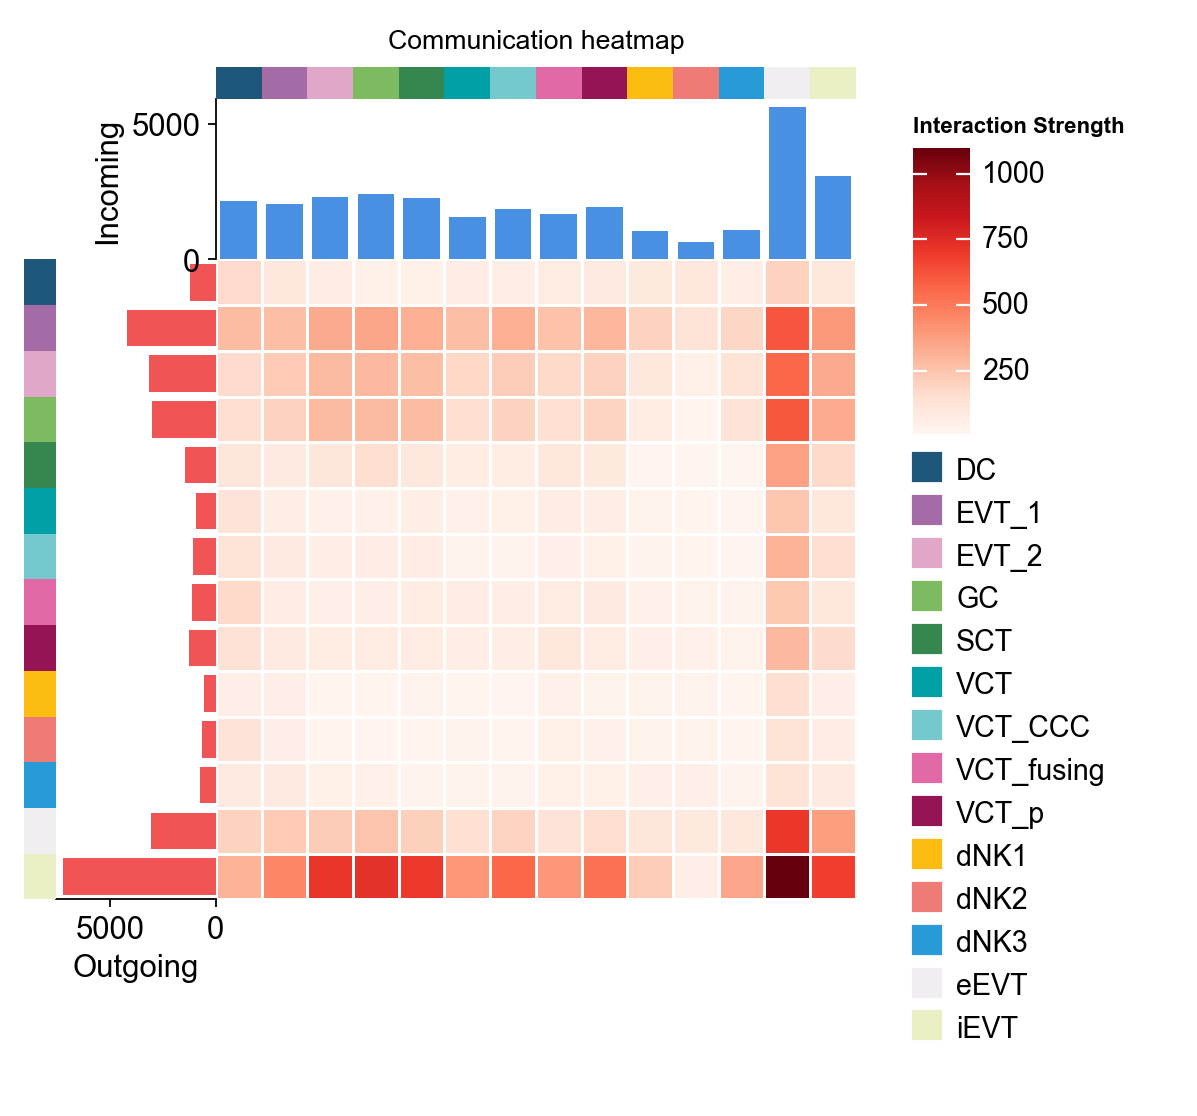

In [7]:
fig, ax = ov.pl.ccc_heatmap(
    adata,
    plot_type='heatmap',
    display_by='aggregation',
    cmap='Reds',
    show=False,
)

   - Found 13 info columns and 196 cell type pairs
   - Found 121 pathway classifications


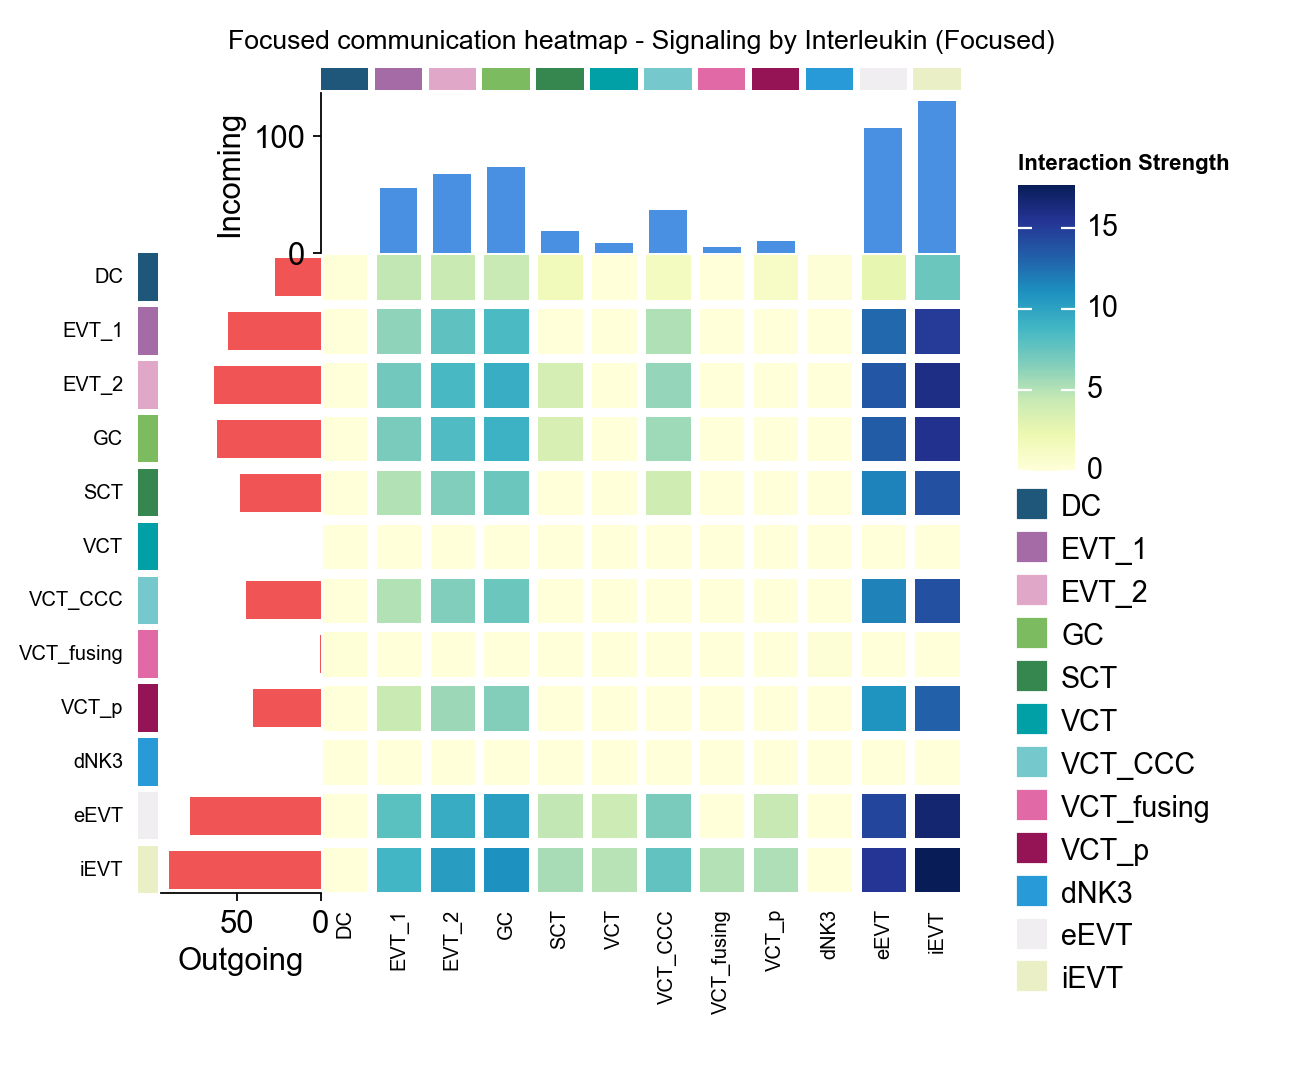

In [8]:
fig, ax = ov.pl.ccc_heatmap(
    adata_plot,
    plot_type='focused_heatmap',
    signaling=['Signaling by Interleukin'],
    min_interaction_threshold=0.1,
    cmap='YlGnBu',
    figsize=(7, 5),
    show=False,
    show_row_names=True,
    show_col_names=True,
)

## 1.2 Dot, pathway bubble, and role-oriented heatmaps


   - Found 13 info columns and 196 cell type pairs
   - Found 121 pathway classifications


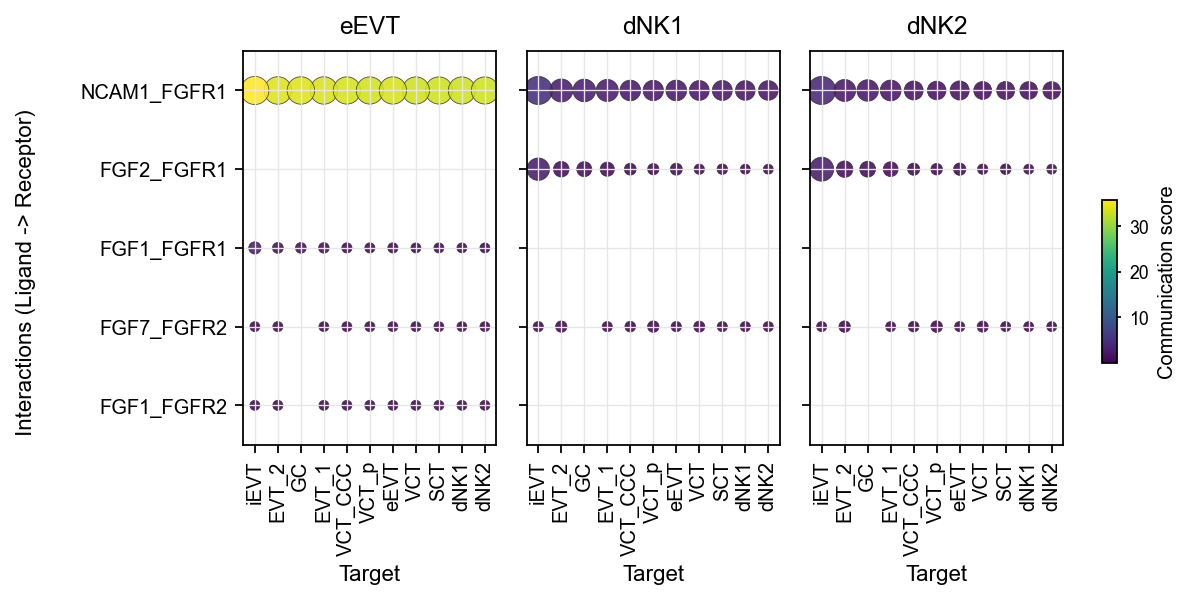

In [9]:
fig, ax = ov.pl.ccc_heatmap(
    adata_plot,
    plot_type='dot',
    sender_use=['eEVT', 'dNK1', 'dNK2'],
    display_by='interaction',
    signaling=[focus_pathway],
    top_n=5,
    cmap='viridis',
    figsize=(8, 3),
    show=False,
)

   - Found 13 info columns and 196 cell type pairs
   - Found 121 pathway classifications
📊 Visualization statistics:
   - Number of significant interactions: 10
   - Number of cell type pairs: 10
   - Signaling pathways: 1
   - Data scaling: None (raw expression values)
   - Color bars: sender


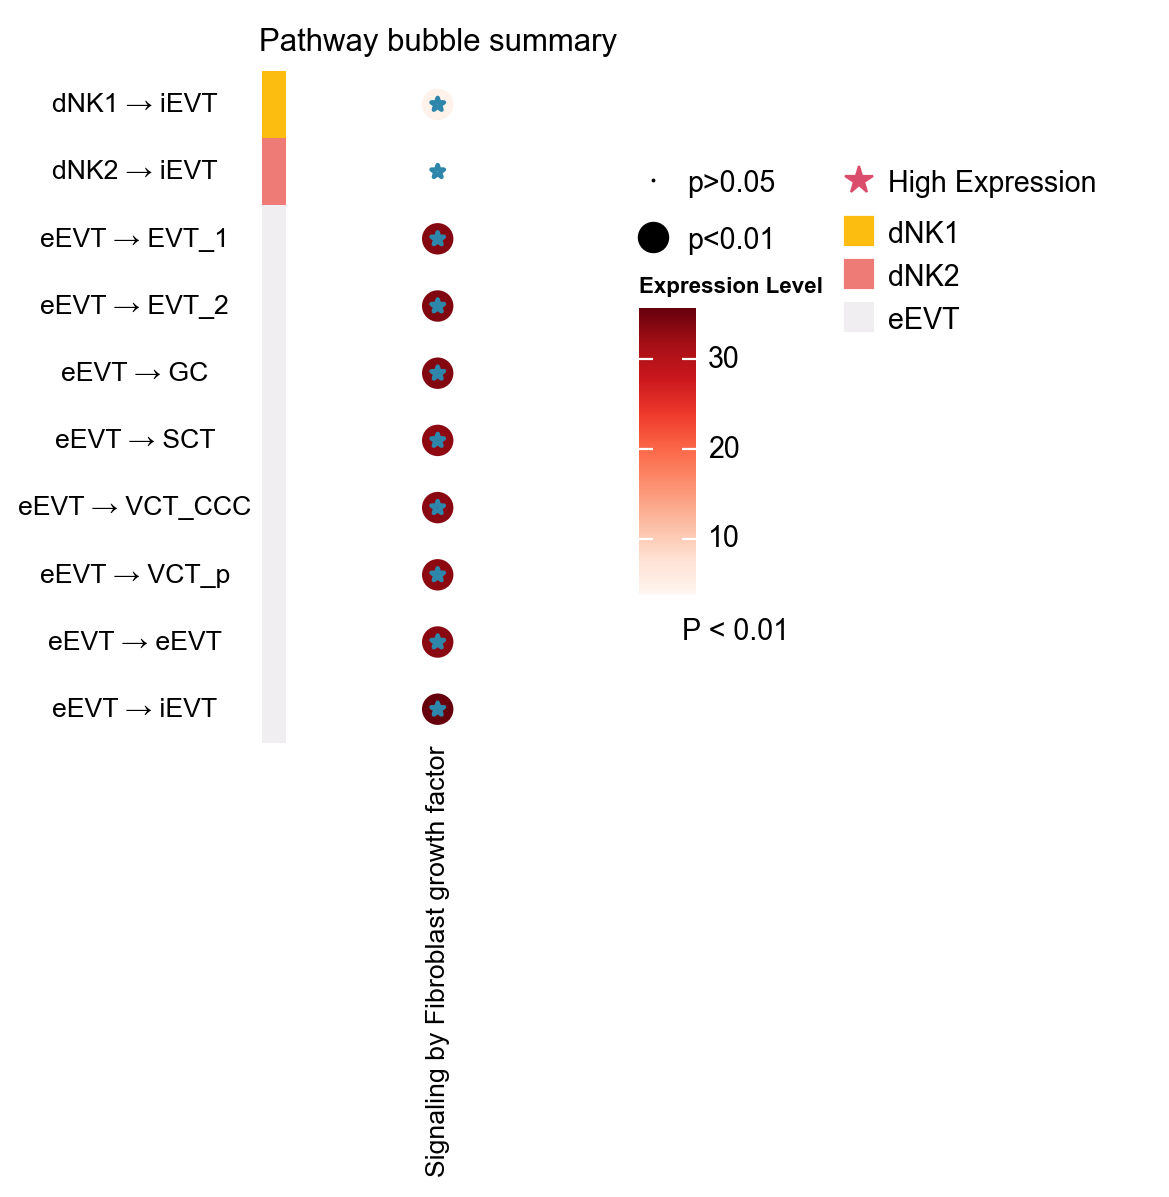

In [10]:
fig, ax = ov.pl.ccc_heatmap(
    adata_plot,
    plot_type='pathway_bubble',
    signaling=[focus_pathway],
    top_n=10,
    figsize=(3, 6),
    show=False,
)

   - Found 13 info columns and 196 cell type pairs
   - Found 121 pathway classifications
🔬 Calculating cell communication strength for 121 pathways...
   - Aggregation method: mean
   - Minimum expression threshold: 0.1


✅ Completed pathway communication strength calculation for 121 pathways
📊 Pathway significance analysis results:
   - Total pathways: 121
   - Significant pathways: 72
   - Strength threshold: 0.5
   - p-value threshold: 0.05

🏆 Top 10 pathways by total strength:
----------------------------------------------------------------------------------------------------
Pathway                        Total    Max     Mean    L-R  Active Sig  Rate   Status
----------------------------------------------------------------------------------------------------
Adhesion by Fibronectin        4488.87  145.91  22.90   12   196    52   0.27   ***
Signaling by Annexin           885.09   26.18   6.32    2    140    7    0.05   ***
Signaling by Placenta growth   829.15   21.65   5.06    4    164    59   0.36   ***
Signaling by Teneurin          734.99   10.64   4.15    12   177    42   0.24   ***
Signaling by Amyloid-beta pr   613.11   26.05   3.18    5    193    62   0.32   ***
Signaling by Steroids      

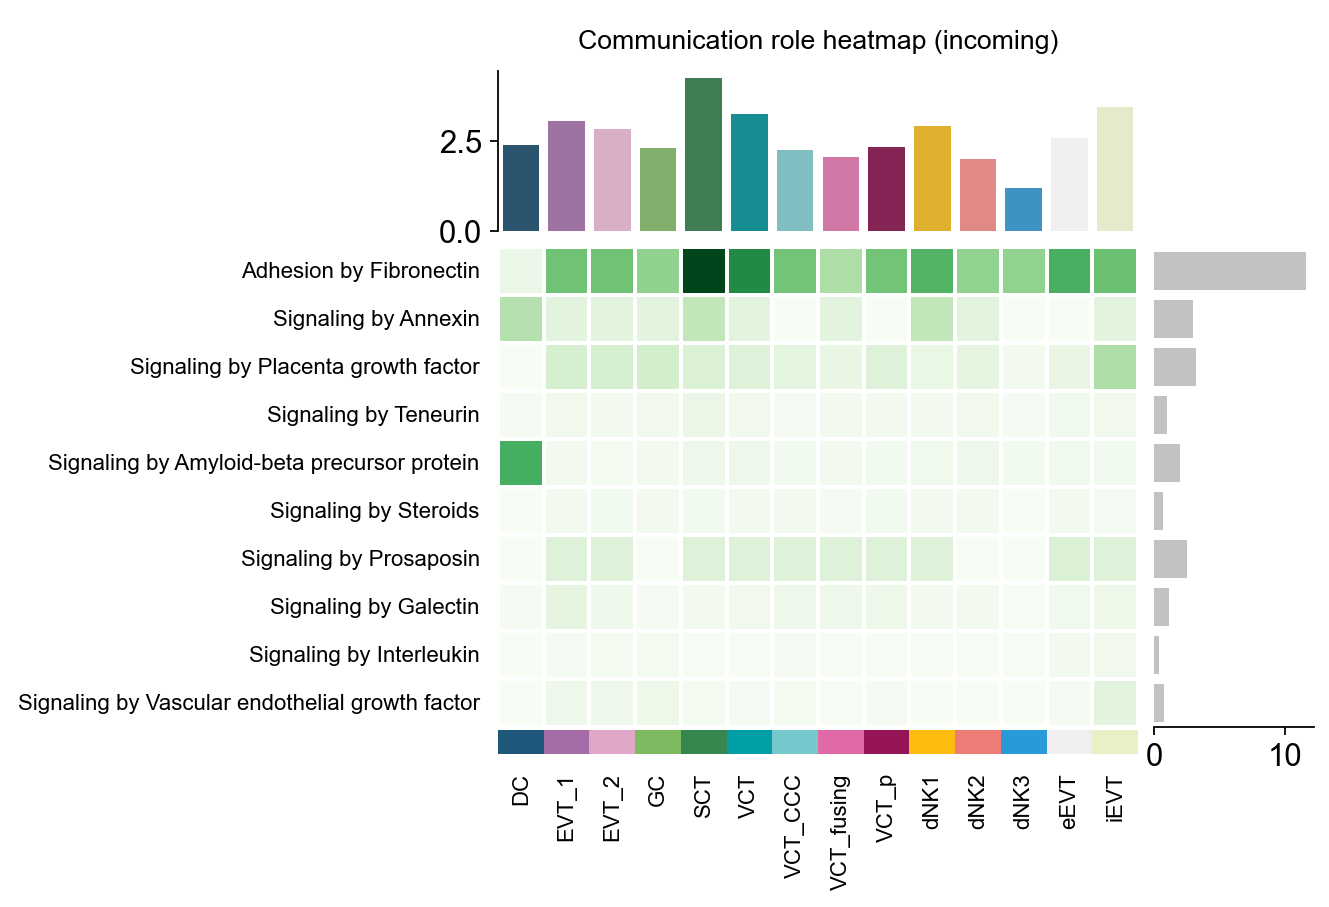

In [11]:
fig, ax = ov.pl.ccc_heatmap(
    adata_plot,
    plot_type='role_heatmap',
    pattern='incoming',
    cmap='Greens',
    top_n=10,
    figsize=(4, 3),
    show=False,
)

   - Found 13 info columns and 196 cell type pairs
   - Found 121 pathway classifications
✅ Network centrality calculation completed (CellChat-style Importance values)
   - Signaling pathways used: ['Signaling by Fibroblast growth factor']
   - Weight mode: Weighted
   - Calculated metrics: outdegree, indegree, flow_betweenness, information, overall
   - All centrality scores normalized to 0-1 range (Importance values)
📊 Signaling role analysis results (Importance values 0-1):
   - Dominant Sender: eEVT (Importance: 1.000)
   - Dominant Receiver: iEVT (Importance: 1.000)
   - Influencer: eEVT (Importance: 1.000)


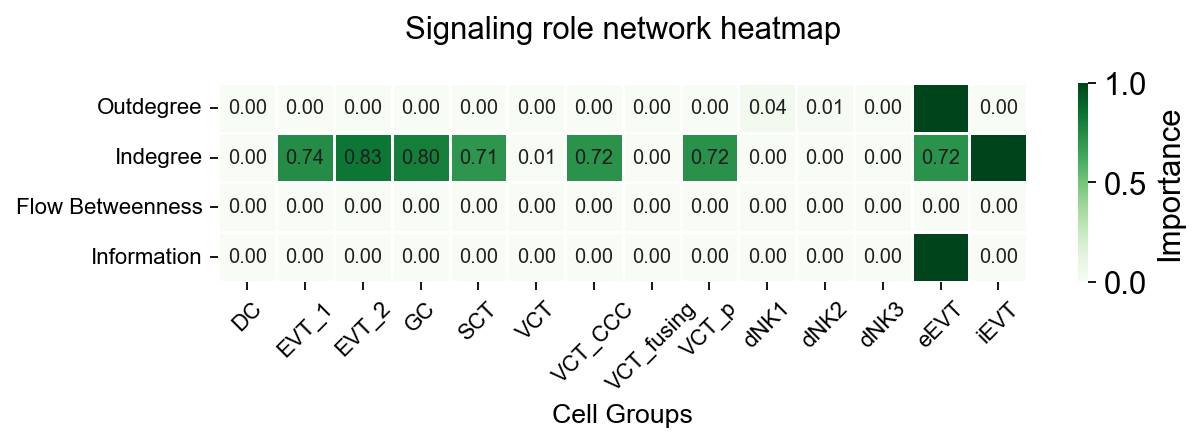

In [12]:
fig, ax = ov.pl.ccc_heatmap(
    adata_plot,
    plot_type='role_network',
    signaling=[focus_pathway],
    cmap='Greens',
    figsize=(8, 3),
    show=False,
)

## 1.3 Differential heatmap


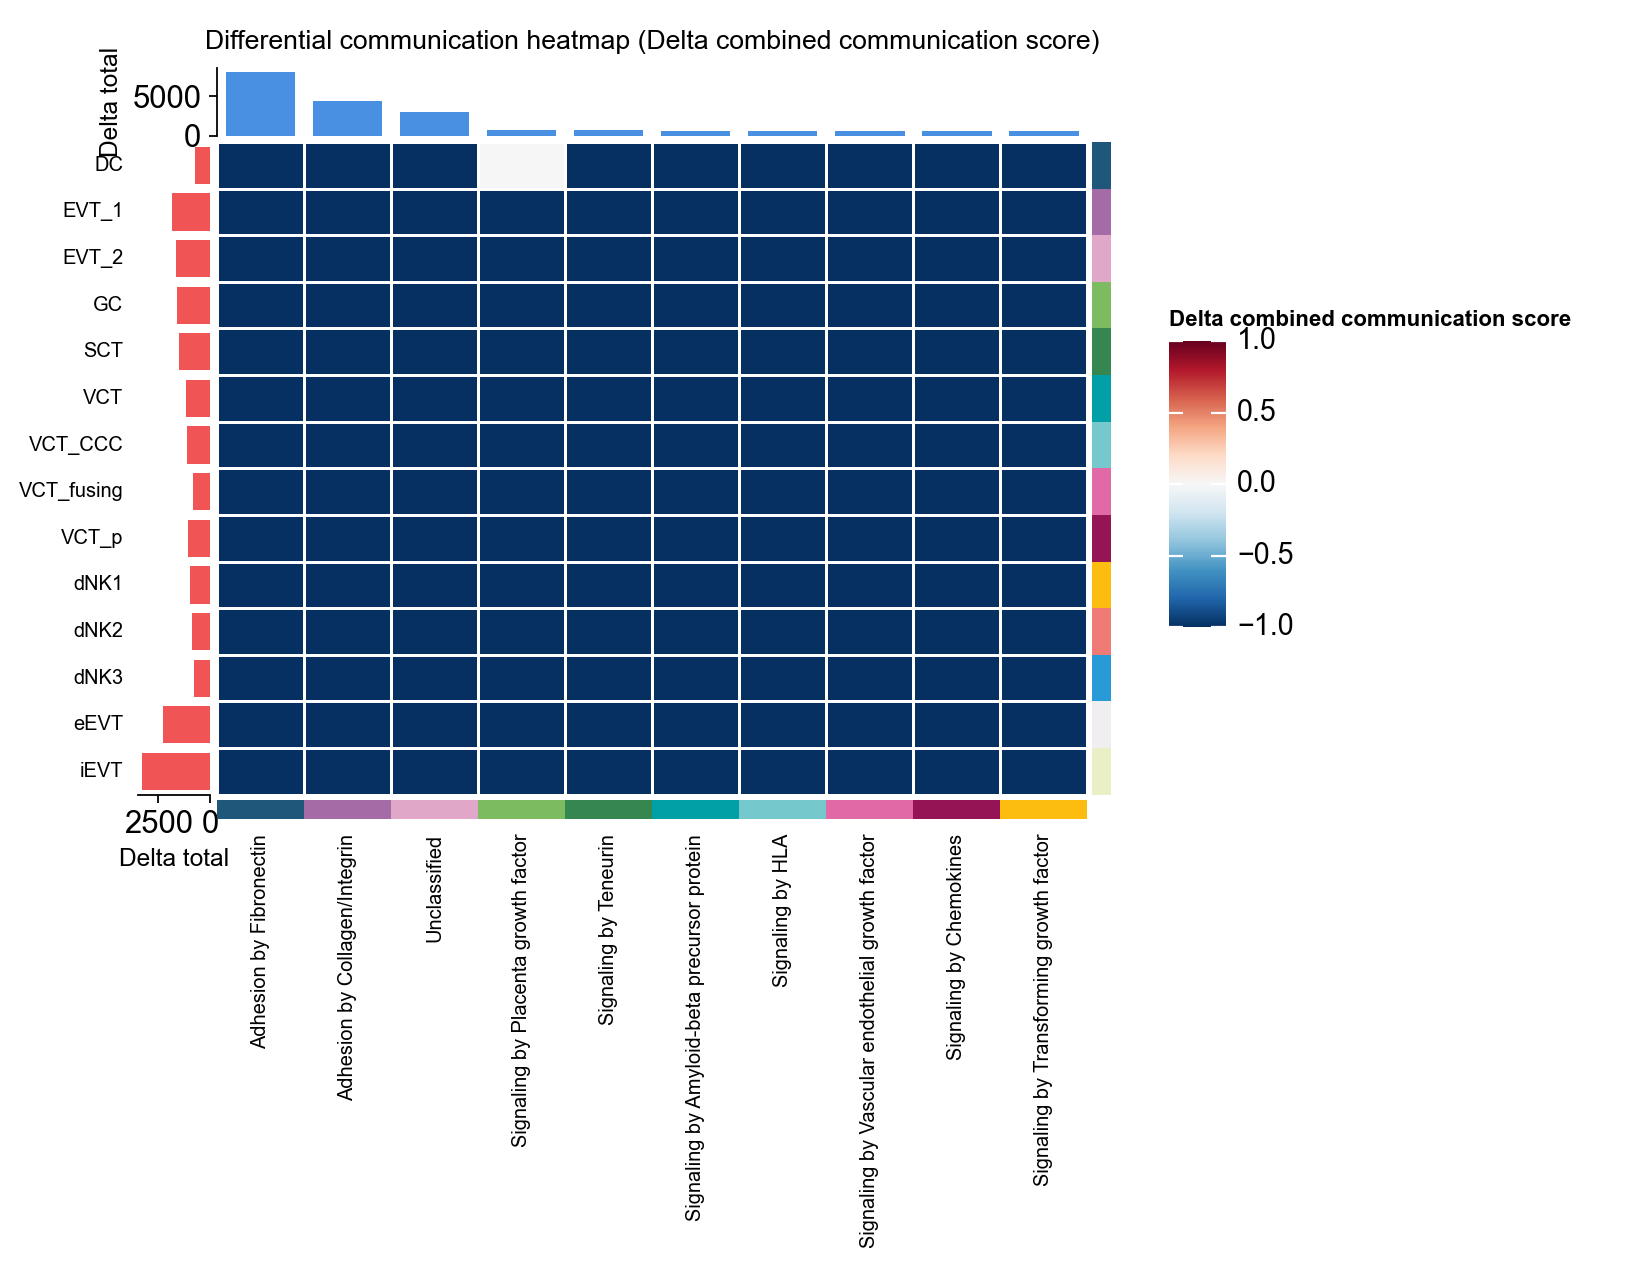

In [13]:
fig, ax = ov.pl.ccc_heatmap(
    comm_adata,
    comparison_adata=comparison_comm,
    plot_type='diff_heatmap',
    top_n=10,
    show=False,
    show_col_names=True,
    show_row_names=True,
)

# 2. `ov.pl.ccc_network_plot`

Network views are useful when you want to understand the global structure and directional flow of the communication graph.


   - Found 13 info columns and 196 cell type pairs
   - Found 121 pathway classifications


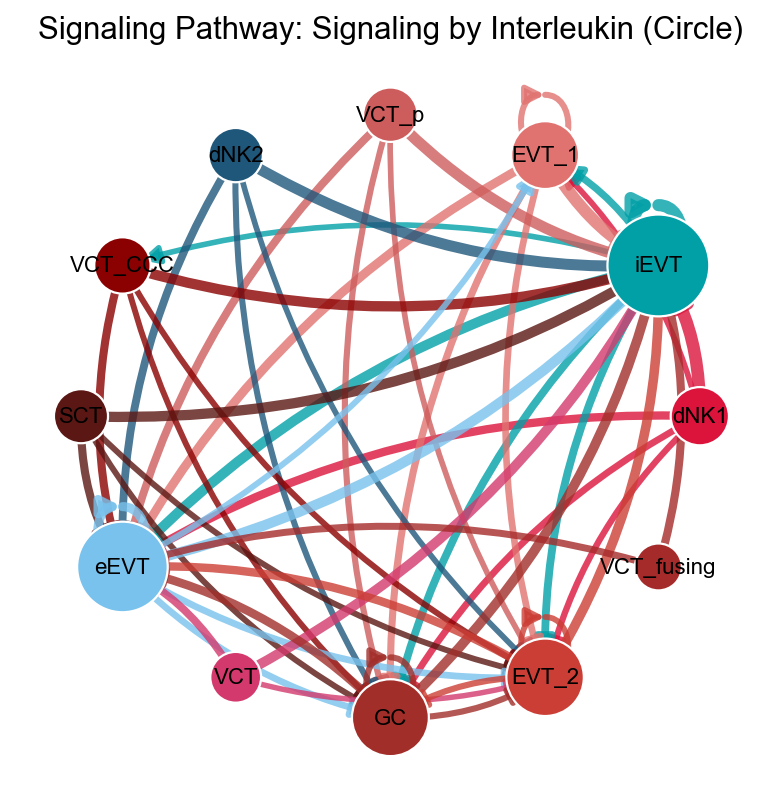

In [14]:
fig, ax = ov.pl.ccc_network_plot(
    adata_plot,
    plot_type='pathway',
    signaling=['Signaling by Interleukin'],
    palette=color_dict,
    top_n=50,
    figsize=(6, 6),
    show=False,
)

   - Found 13 info columns and 196 cell type pairs
   - Found 121 pathway classifications


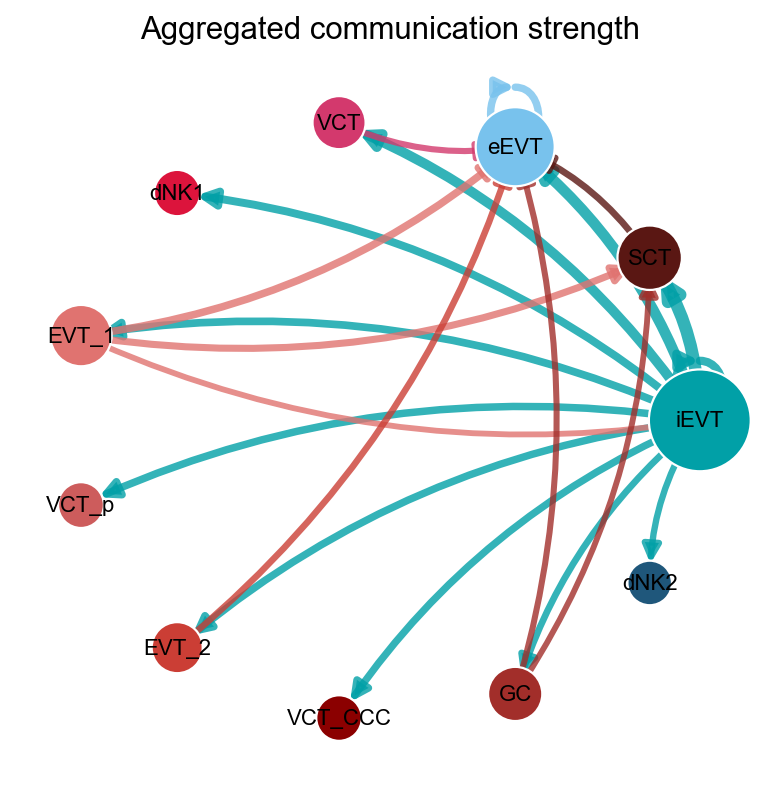

In [15]:
fig, ax = ov.pl.ccc_network_plot(
    adata_plot,
    plot_type='circle',
    palette=color_dict,
    title='Aggregated communication strength',
    figsize=(6, 6),
    show=False,
)

   - Found 13 info columns and 196 cell type pairs
   - Found 121 pathway classifications


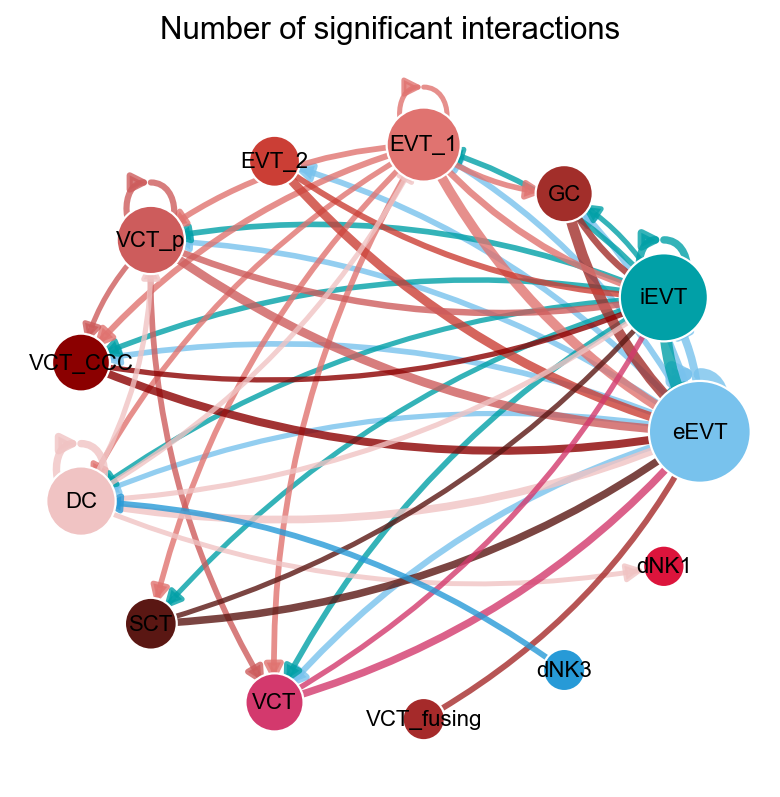

In [16]:
fig, ax = ov.pl.ccc_network_plot(
    adata_plot,
    plot_type='circle',
    value='count',
    palette=color_dict,
    top_n=50,
    title='Number of significant interactions',
    figsize=(6, 6),
    show=False,
)

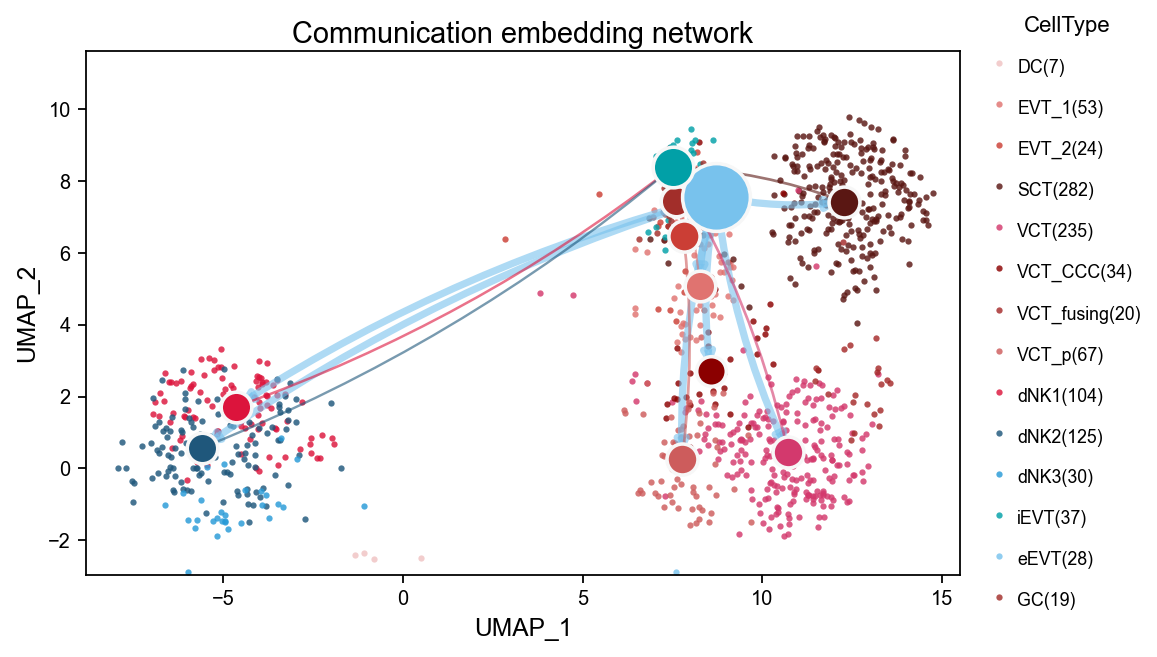

In [17]:
fig, ax = ov.pl.ccc_network_plot(
    comm_adata,
    plot_type='embedding_network',
    signaling=[focus_pathway],
    node_positions=node_positions,
    embedding_points=embedding_points,
    palette=color_dict,
    top_n=20,
    figsize=(7, 7),
    show=False,
)

   - Found 13 info columns and 196 cell type pairs
   - Found 121 pathway classifications


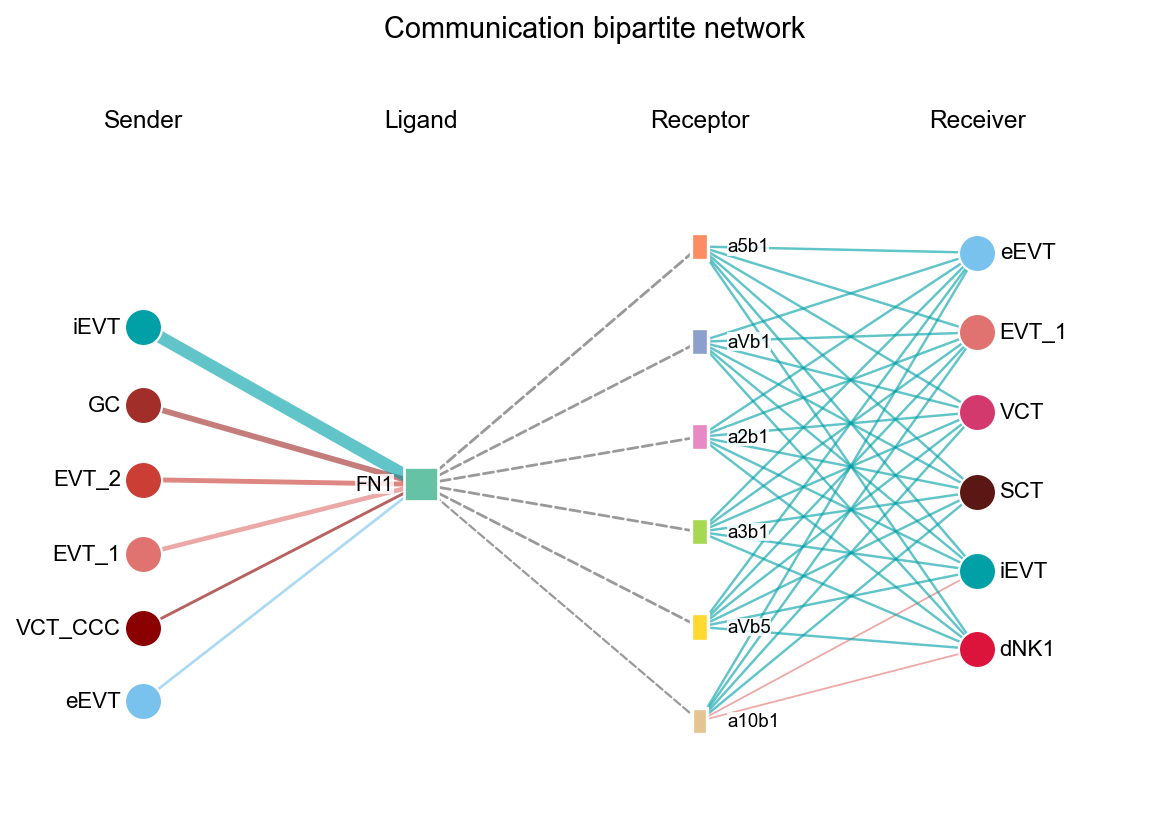

In [18]:
fig, ax = ov.pl.ccc_network_plot(
    adata,
    plot_type='bipartite',
    ligand=focus_ligand,
    palette=color_dict,
    top_n=6,
    figsize=(8, 6),
    show=False,
)

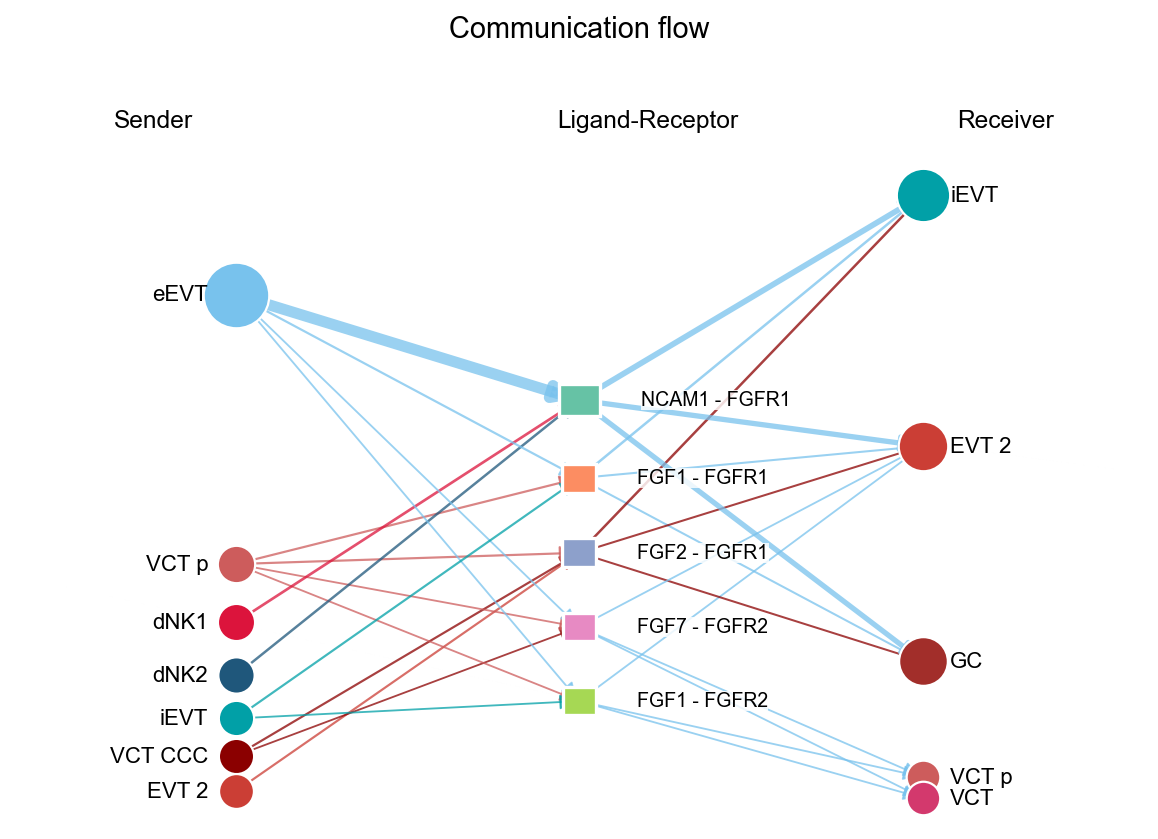

In [19]:
fig, ax = ov.pl.ccc_network_plot(
    comm_adata,
    plot_type='arrow',
    display_by='interaction',
    signaling=[focus_pathway],
    palette=color_dict,
    top_n=5,
    figsize=(8, 6),
    show=False,
)

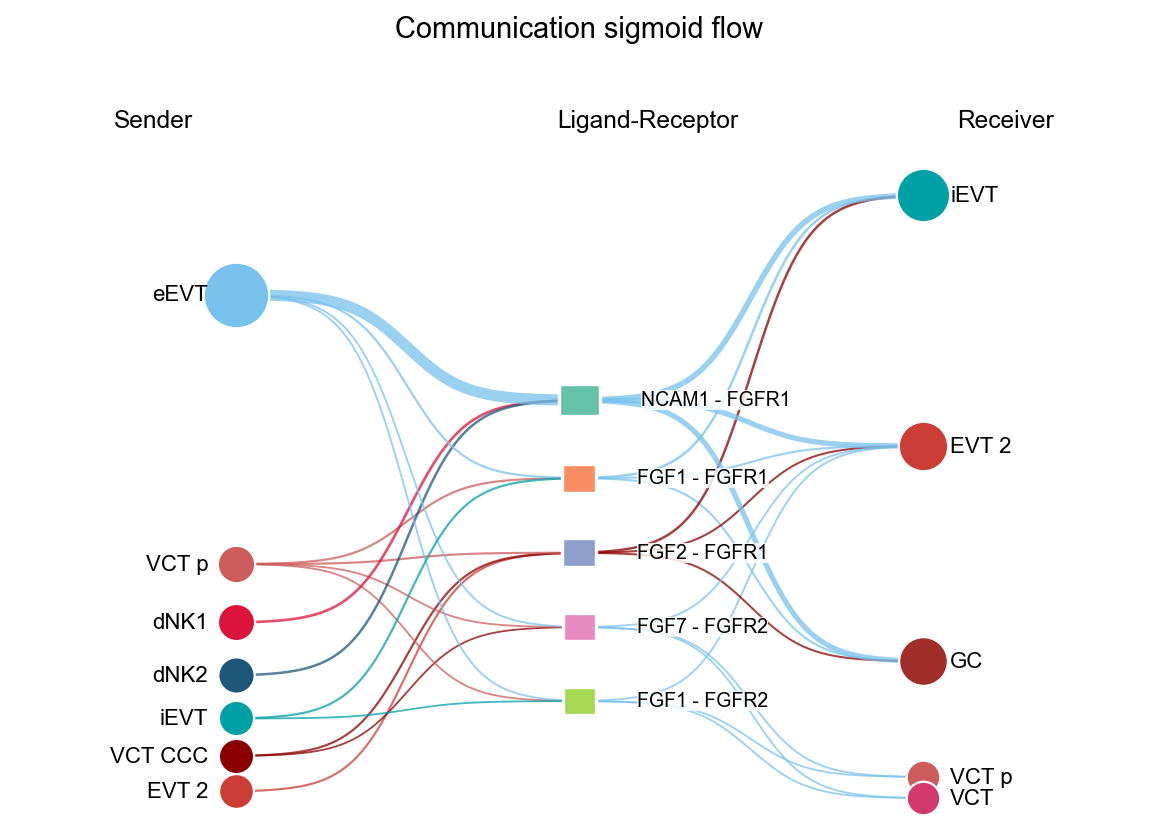

In [20]:
fig, ax = ov.pl.ccc_network_plot(
    comm_adata,
    plot_type='sigmoid',
    display_by='interaction',
    signaling=[focus_pathway],
    palette=color_dict,
    top_n=5,
    figsize=(8, 6),
    show=False,
)

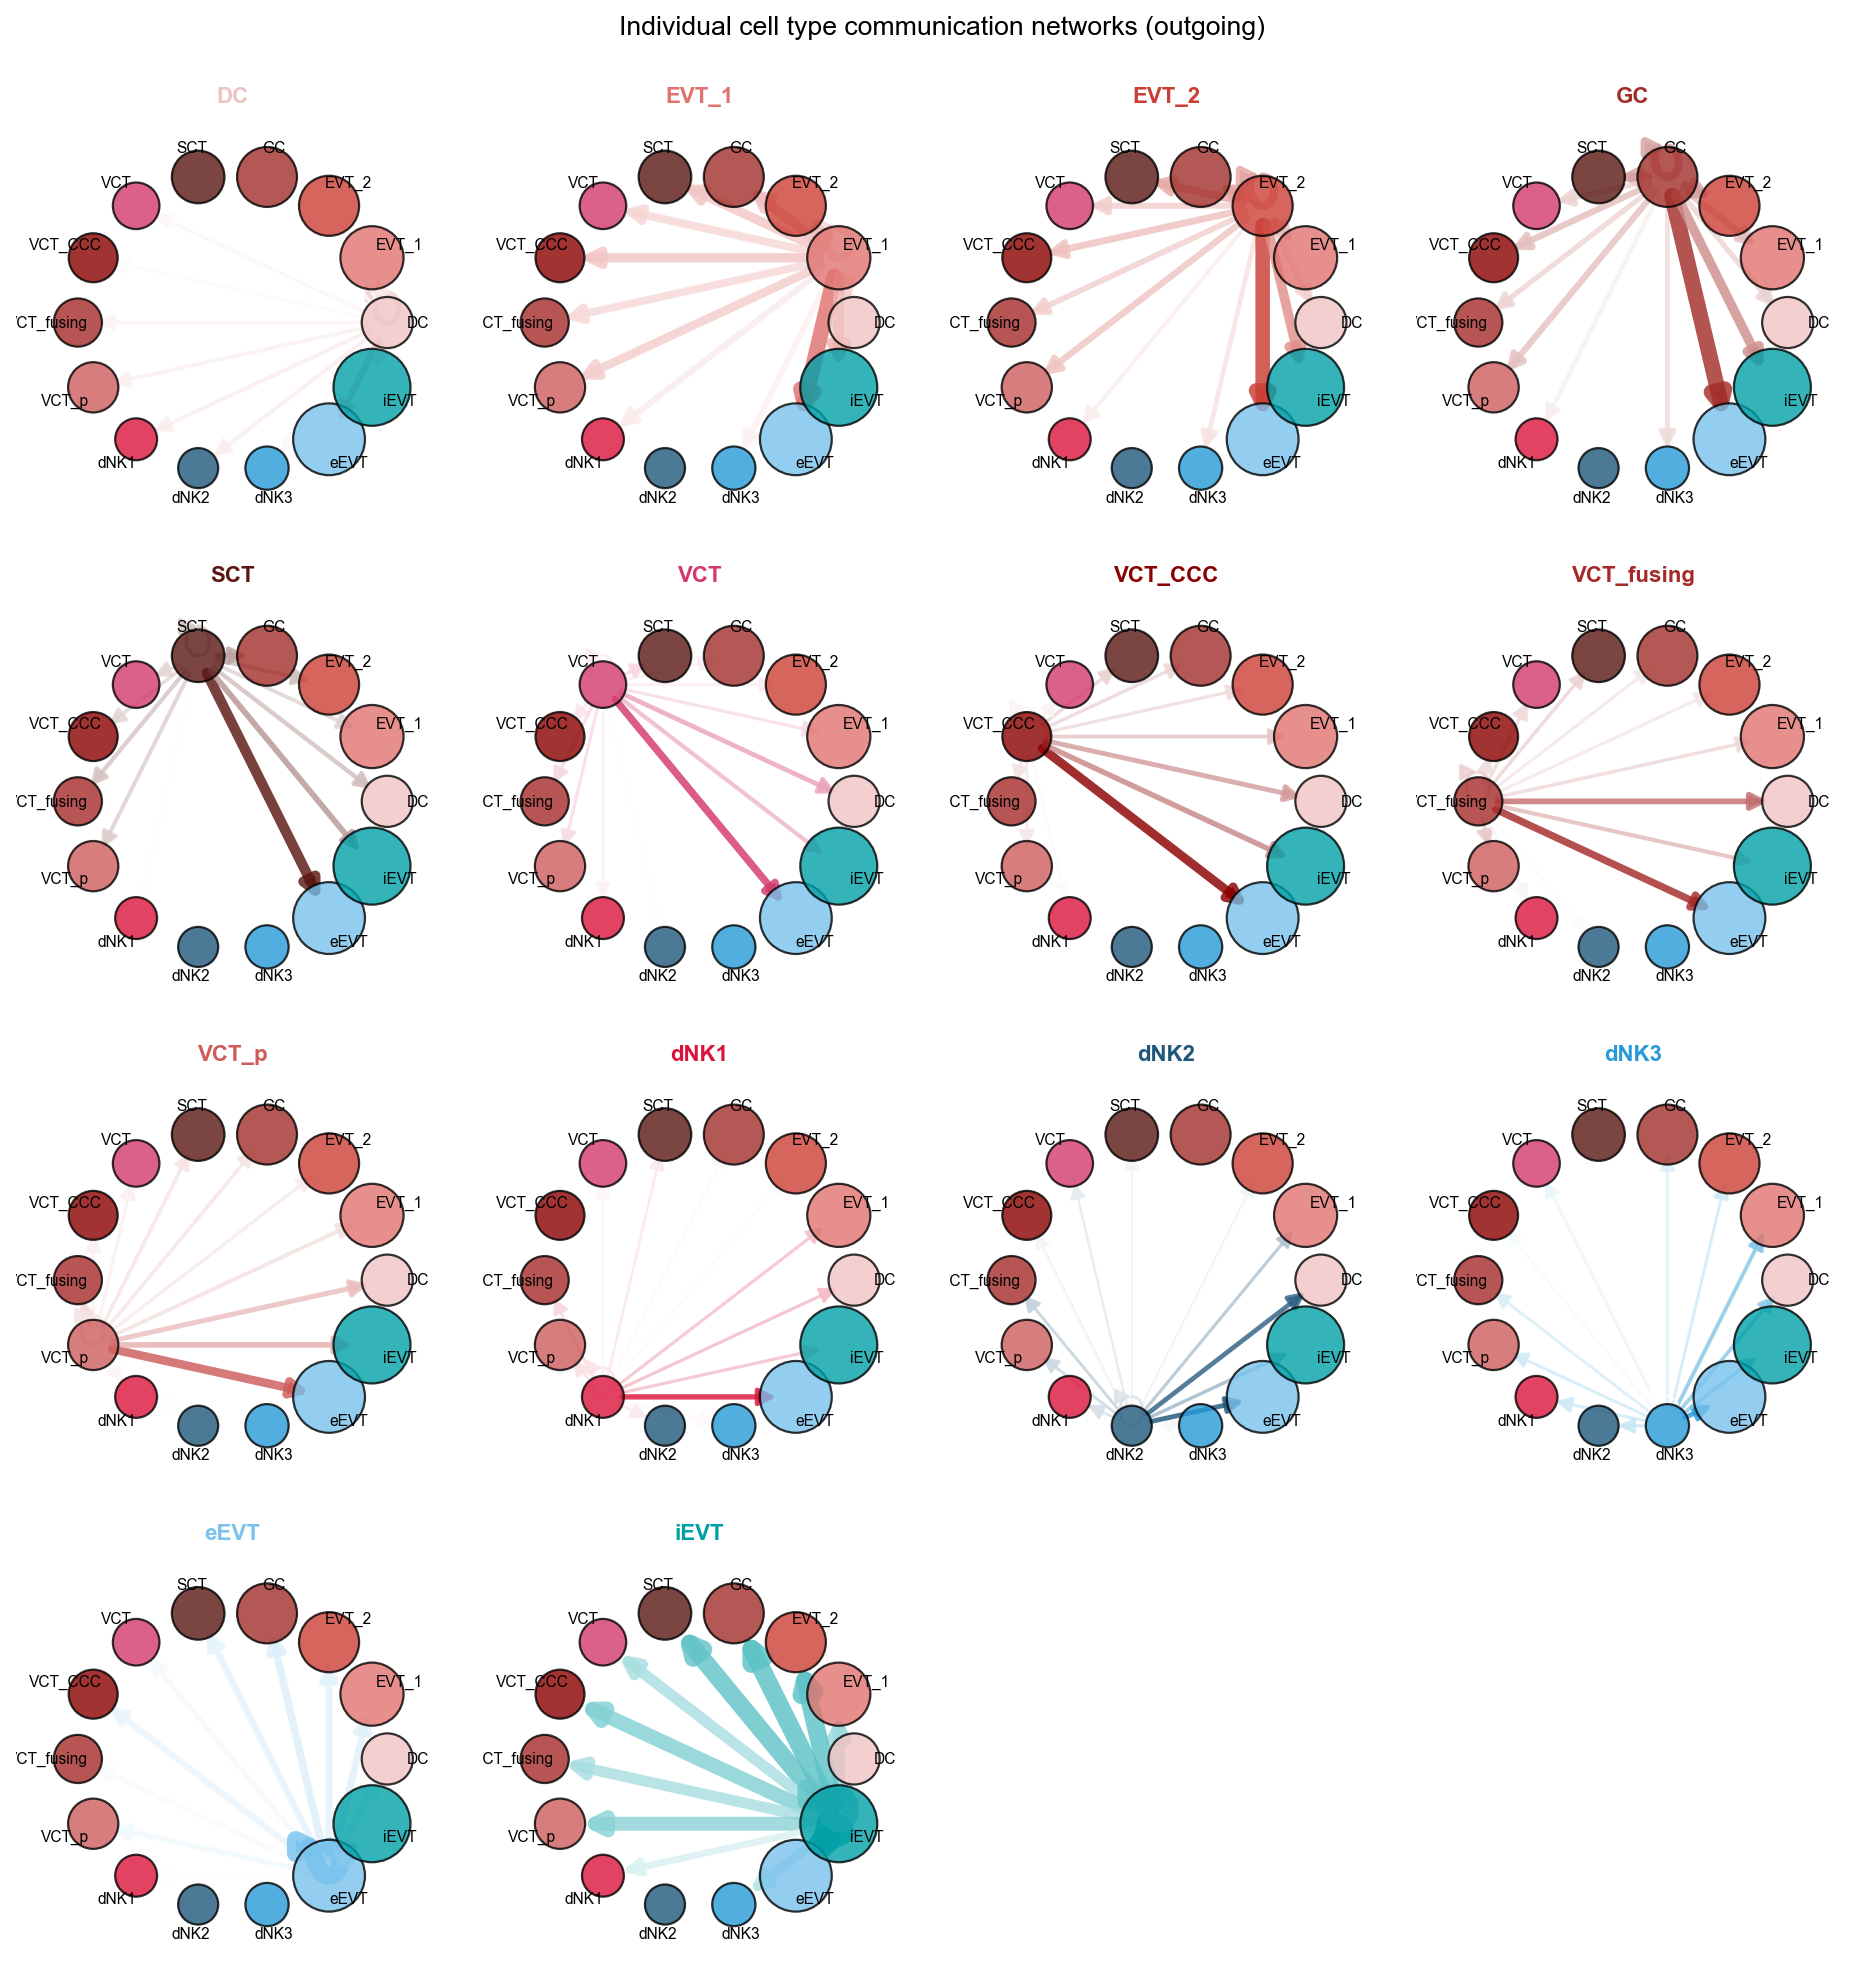

In [21]:
fig, ax = ov.pl.ccc_network_plot(
    comm_adata,
    plot_type='individual_outgoing',
    palette=color_dict,
    figsize=(12, 13),
    show=False,
)

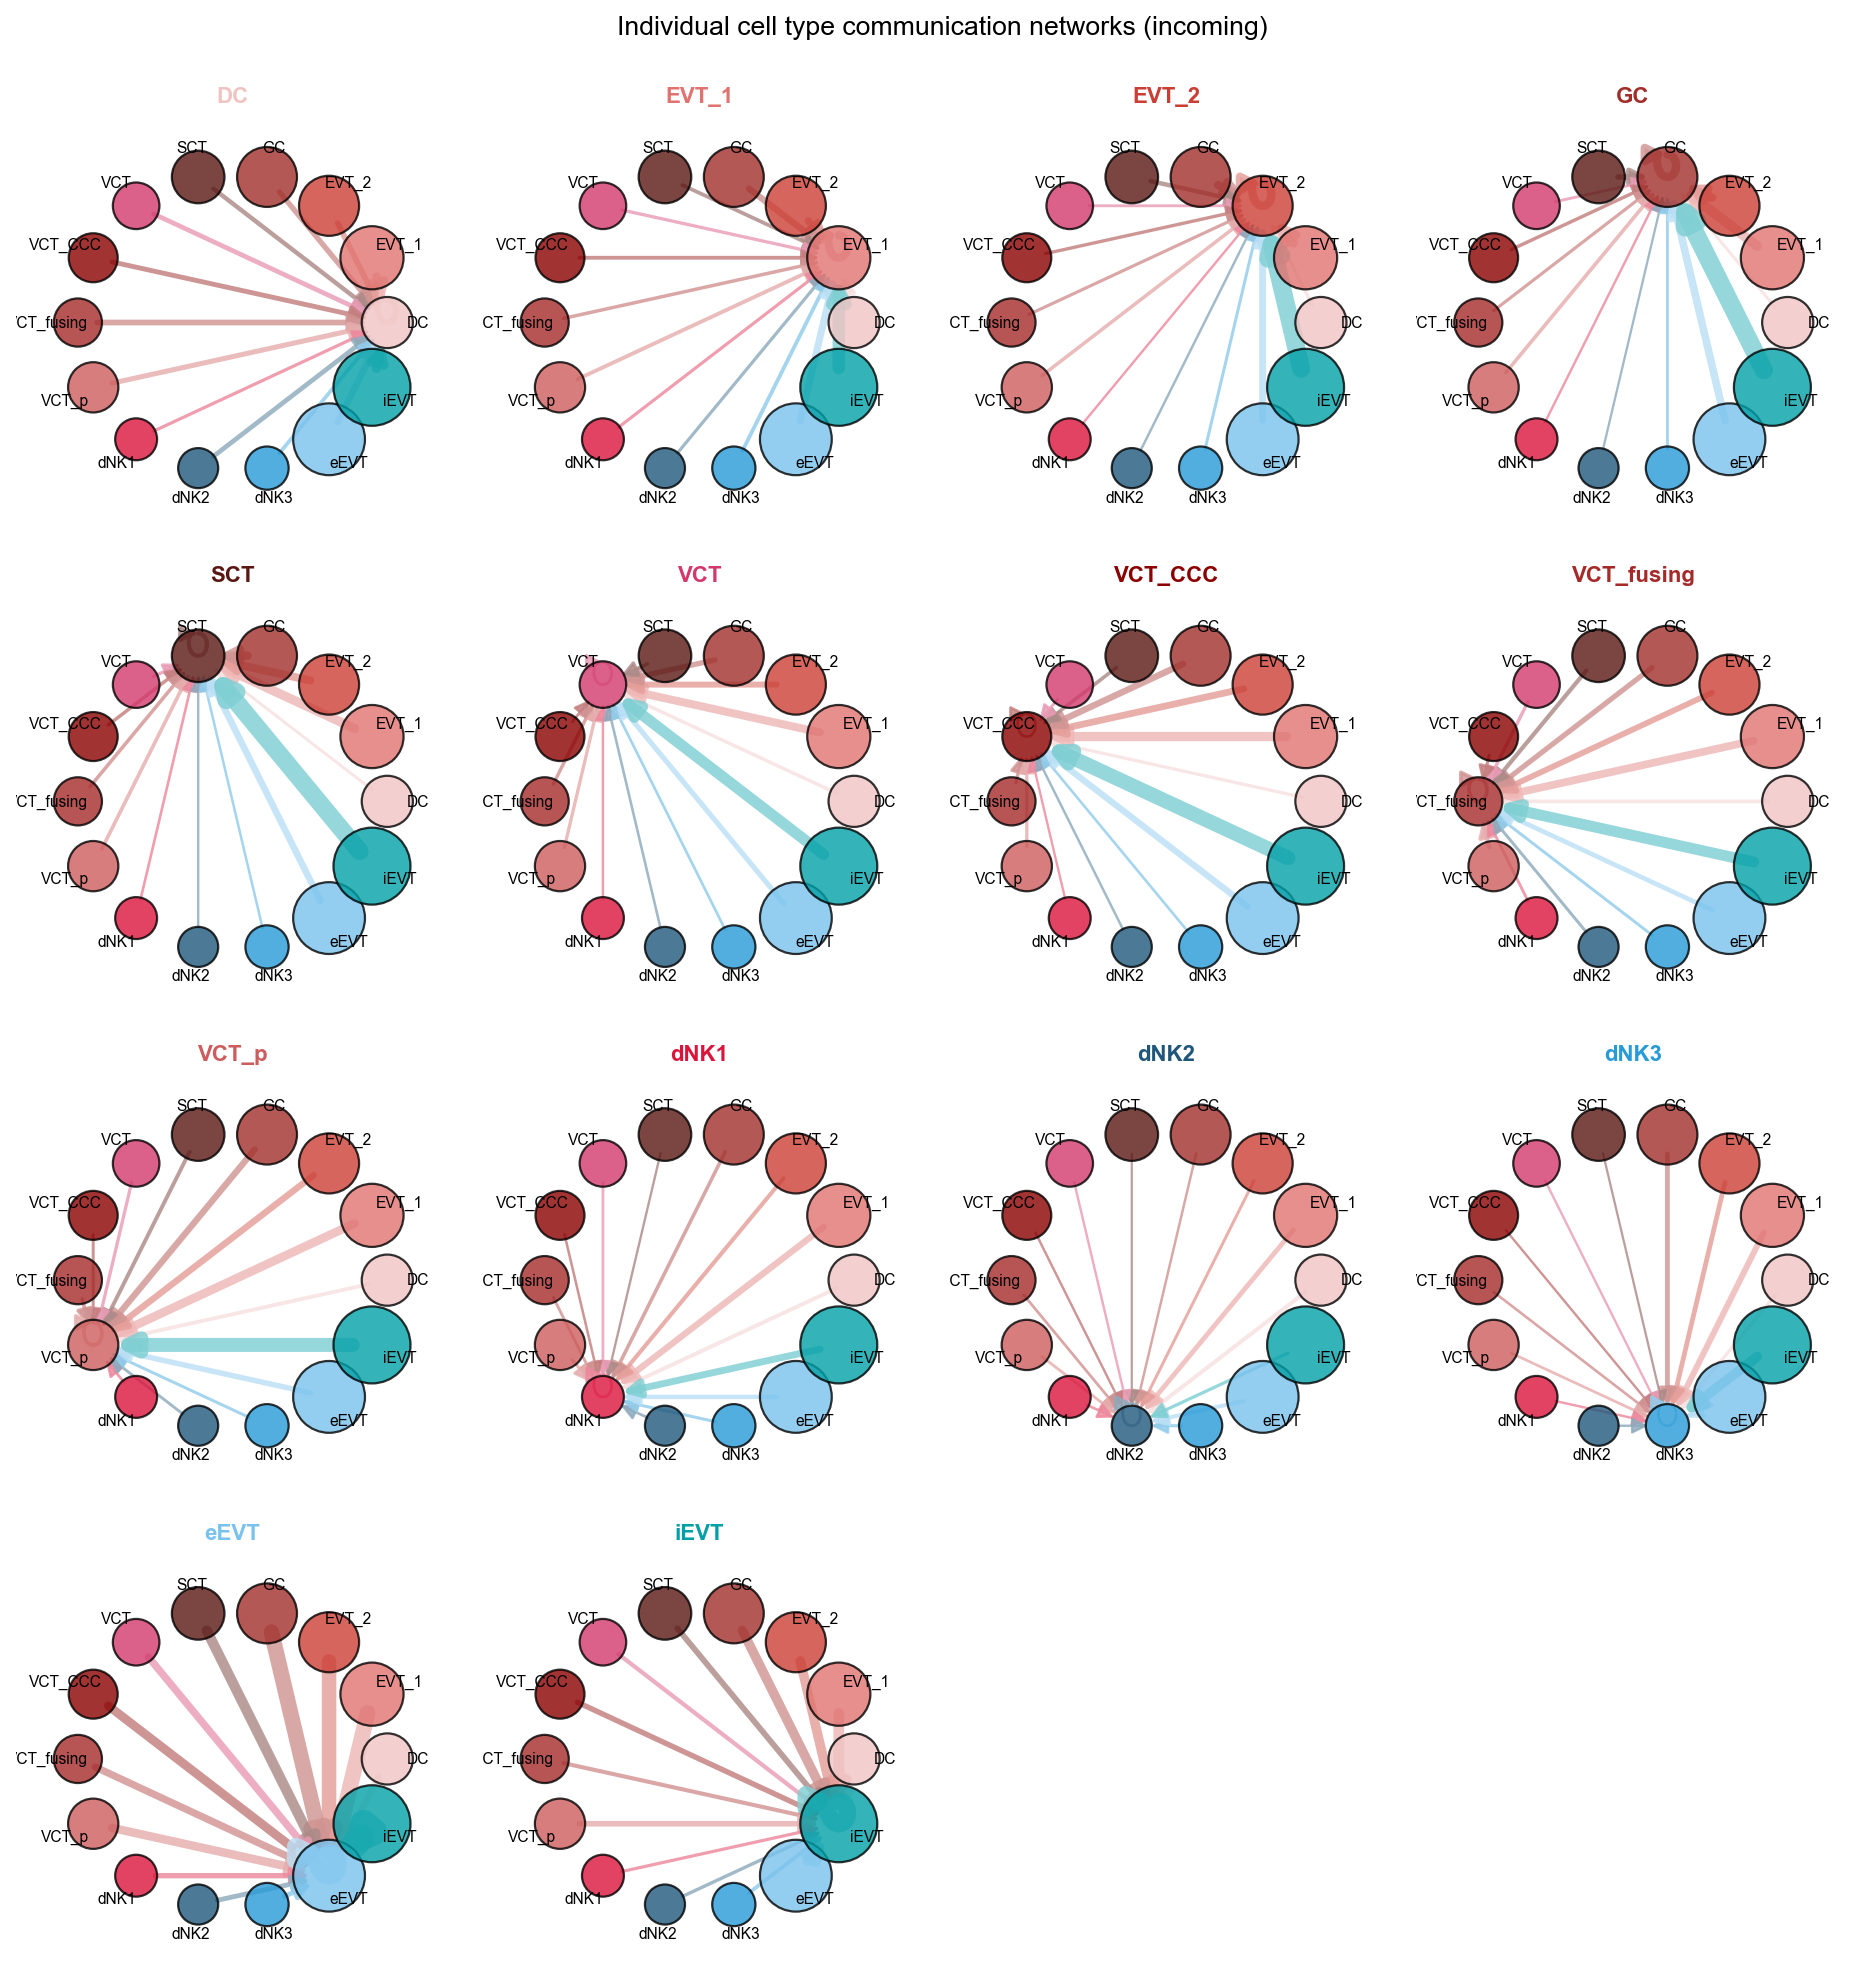

In [22]:
fig, ax = ov.pl.ccc_network_plot(
    comm_adata,
    plot_type='individual_incoming',
    palette=color_dict,
    figsize=(12, 13),
    show=False,
)

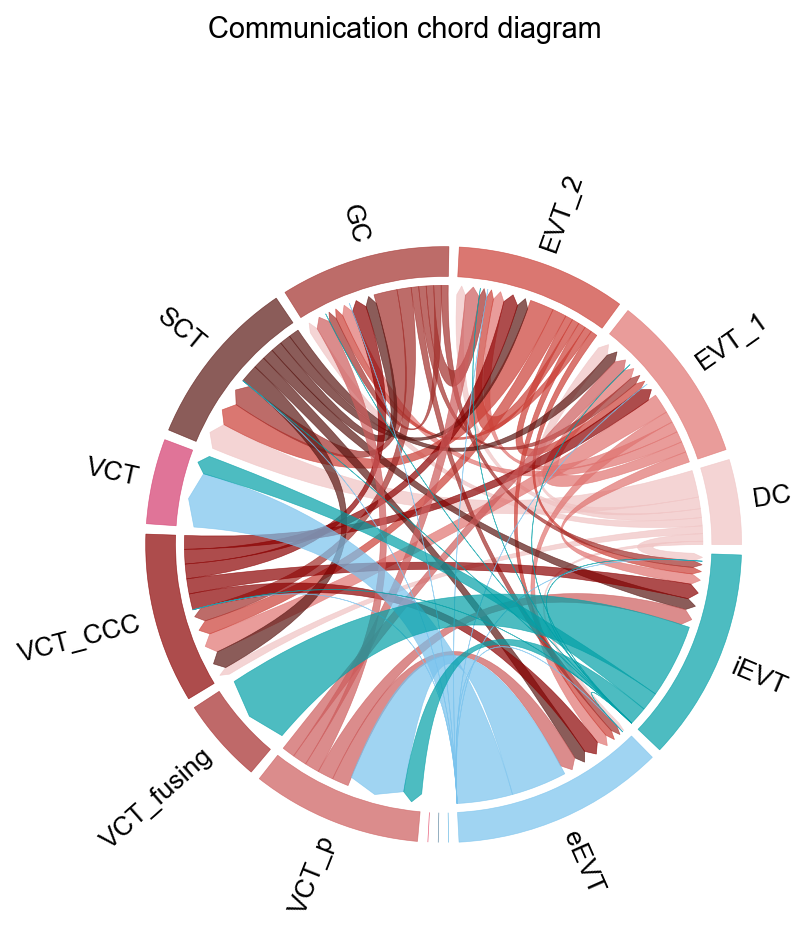

In [23]:
fig, ax = ov.pl.ccc_network_plot(
    comm_adata,
    plot_type='chord',
    signaling=['Signaling by Interleukin'],
    palette=color_dict,
    normalize_to_sender=True,
    figsize=(6, 6),
    show=False,
)

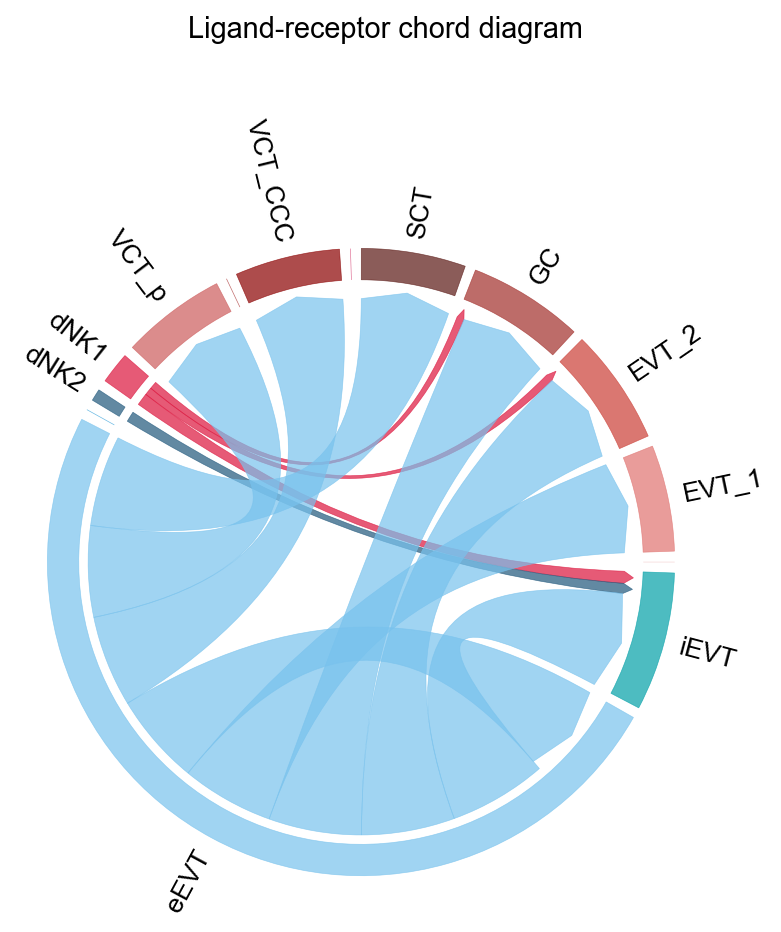

In [24]:
fig, ax = ov.pl.ccc_network_plot(
    comm_adata,
    plot_type='lr_chord',
    pair_lr_use=focus_pair_lr,
    palette=color_dict,
    figsize=(6, 6),
    show=False,
)

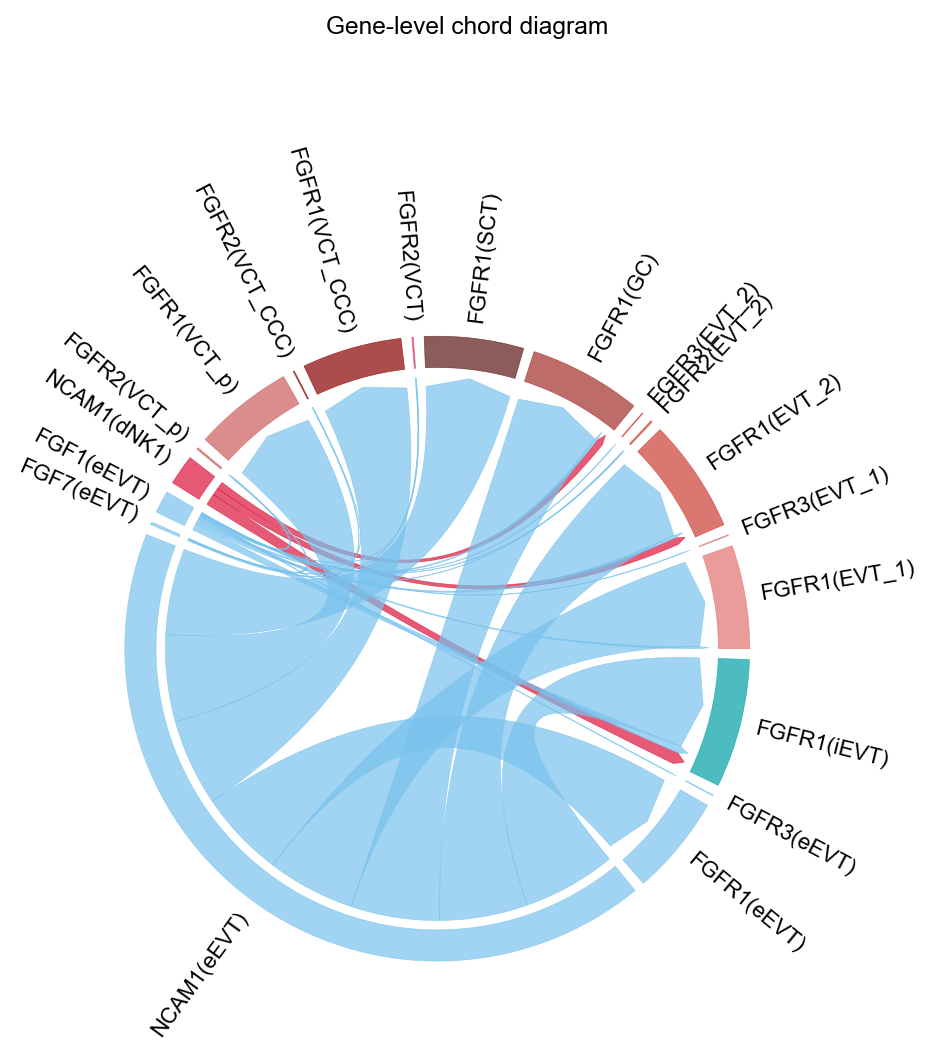

In [25]:
fig, ax = ov.pl.ccc_network_plot(
    comm_adata,
    plot_type='gene_chord',
    signaling=['Signaling by Fibroblast growth factor'],
    sender_use=['eEVT', 'dNK1'],
    palette=color_dict,
    figsize=(6, 7),
    show=False,
)

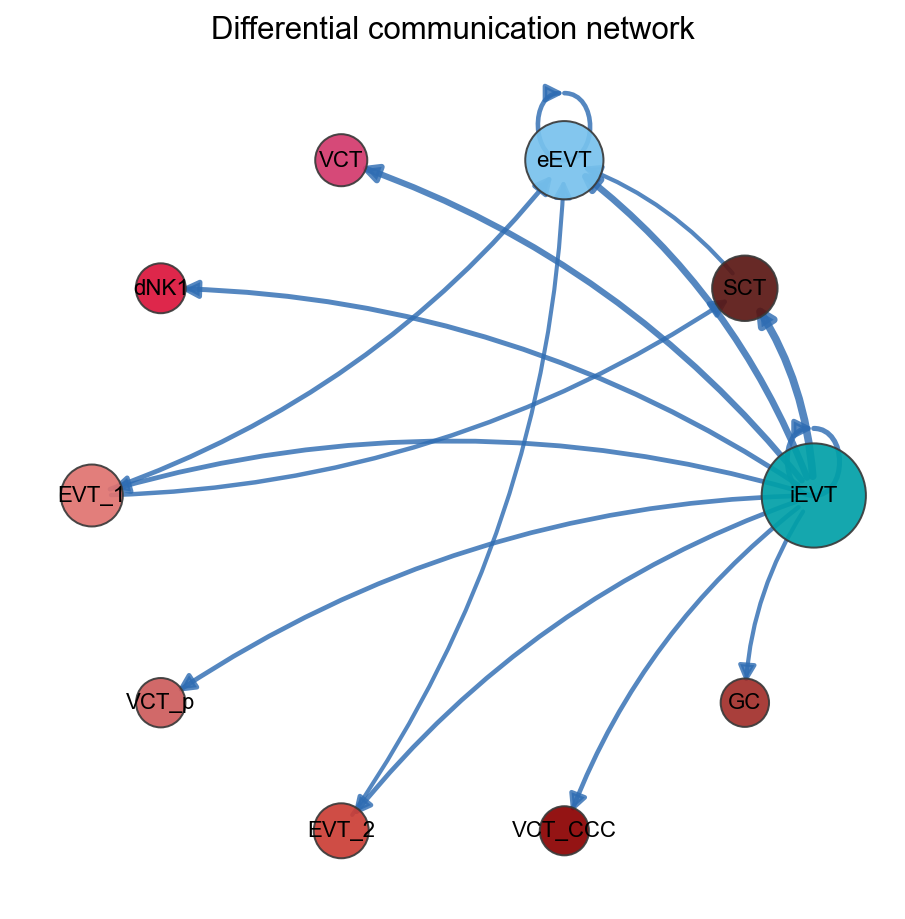

In [26]:
fig, ax = ov.pl.ccc_network_plot(
    comm_adata,
    comparison_adata=comparison_comm,
    plot_type='diff_network',
    palette=color_dict,
    top_n=15,
    show=False,
)

# 3. `ov.pl.ccc_stat_plot`

Statistical summary plots are the compact layer for ranking, contribution analysis, and pathway-level compression.


   - Found 13 info columns and 196 cell type pairs
   - Found 121 pathway classifications


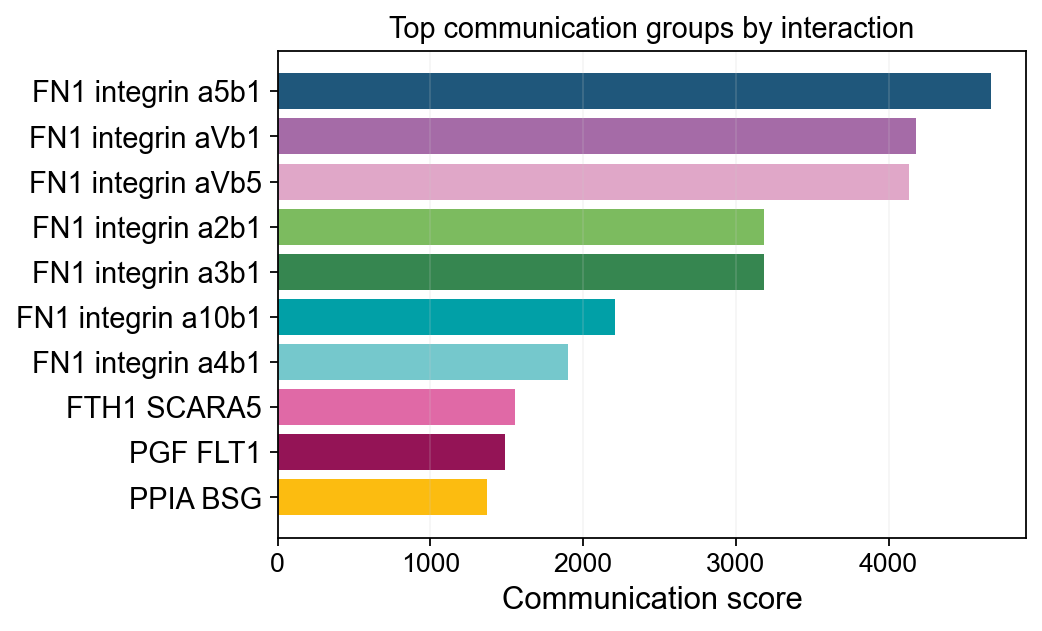

In [27]:
fig, ax = ov.pl.ccc_stat_plot(
    adata_plot,
    plot_type='bar',
    figsize=(6, 4),
    top_n=10,
    show=False,
)

   - Found 13 info columns and 196 cell type pairs
   - Found 121 pathway classifications


✅ Network centrality calculation completed (CellChat-style Importance values)
   - Signaling pathways used: All pathways
   - Weight mode: Weighted
   - Calculated metrics: outdegree, indegree, flow_betweenness, information, overall
   - All centrality scores normalized to 0-1 range (Importance values)


Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


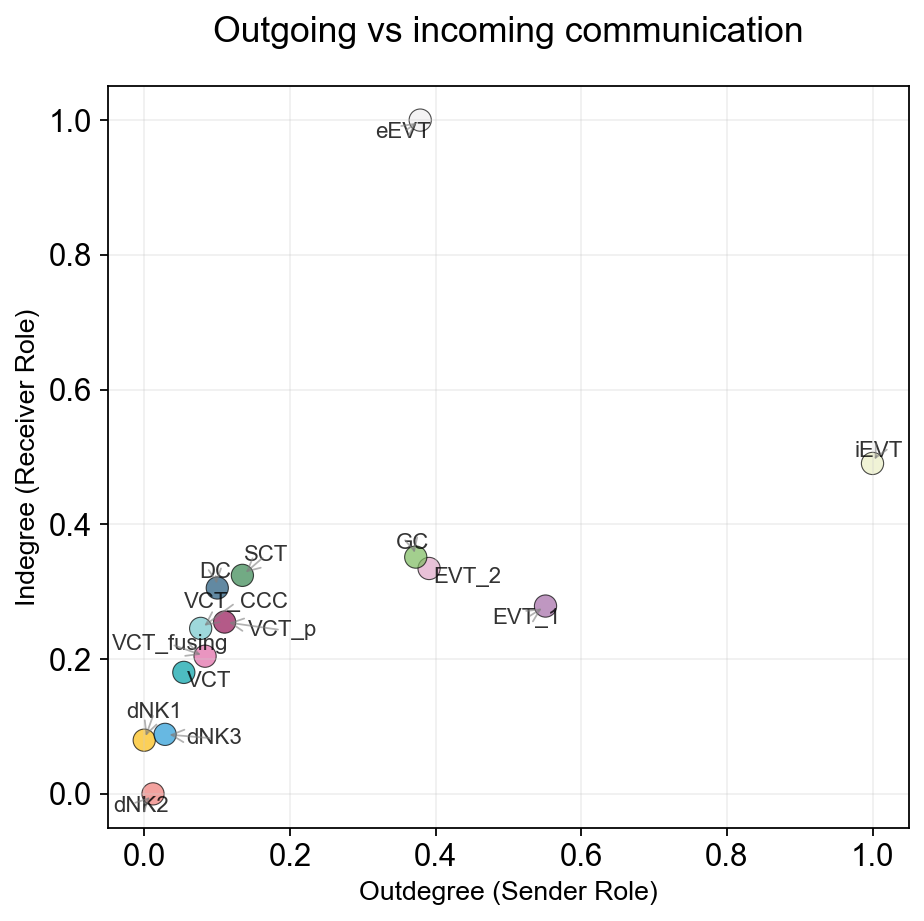

In [28]:
fig, ax = ov.pl.ccc_stat_plot(
    adata_plot,
    plot_type='scatter',
    figsize=(6, 6),
    show=False,
)

   - Found 13 info columns and 196 cell type pairs
   - Found 121 pathway classifications


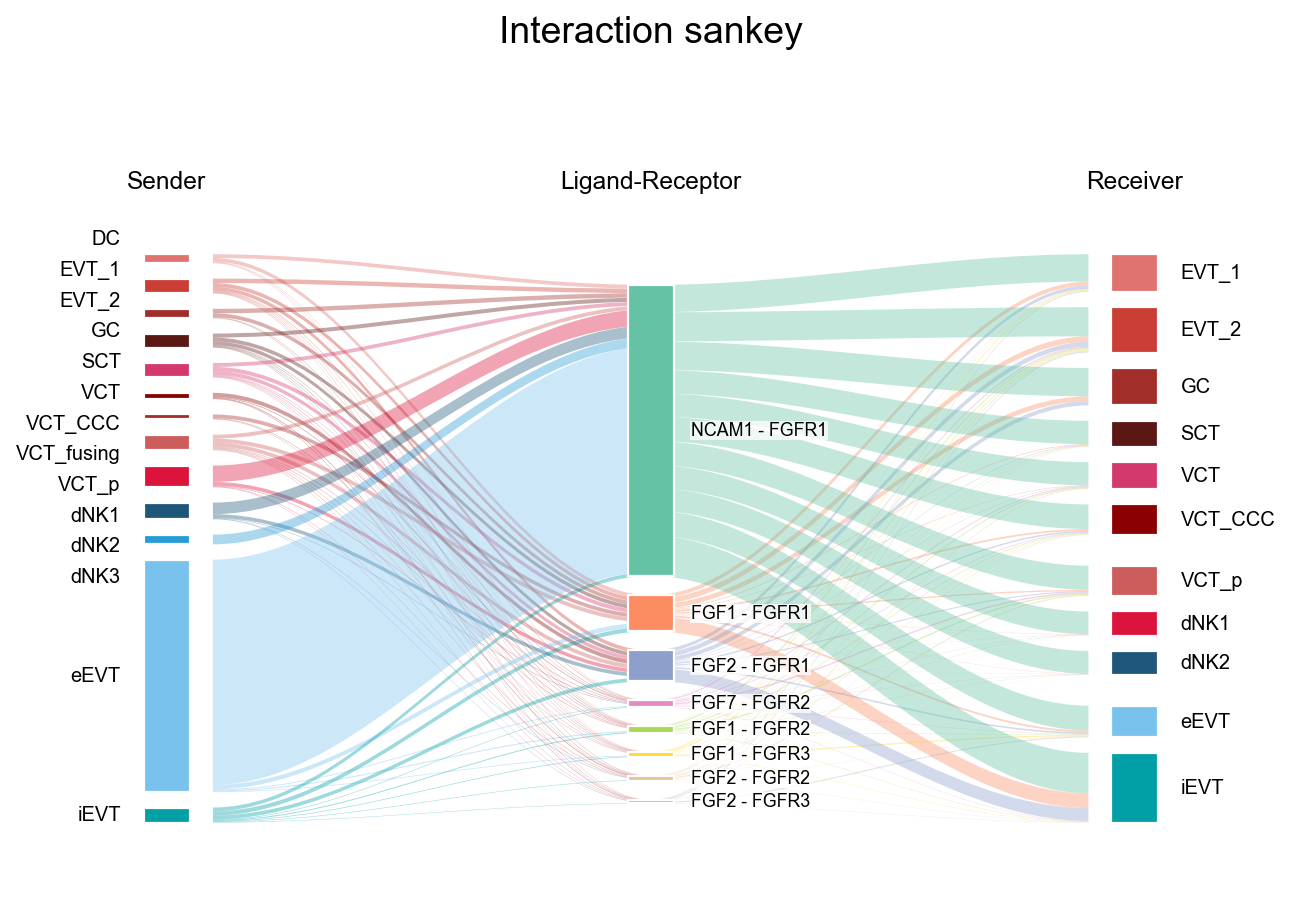

In [29]:
fig, ax = ov.pl.ccc_stat_plot(
    adata_plot,
    plot_type='sankey',
    display_by='interaction',
    signaling=[focus_pathway],
    palette=color_dict,
    top_n=8,
    figsize=(8, 6),
    show=False,
)

   - Found 13 info columns and 196 cell type pairs
   - Found 121 pathway classifications
🔬 Calculating cell communication strength for 121 pathways...
   - Aggregation method: mean
   - Minimum expression threshold: 0.1


✅ Completed pathway communication strength calculation for 121 pathways
📊 Pathway significance analysis results:
   - Total pathways: 121
   - Significant pathways: 72
   - Strength threshold: 0.5
   - p-value threshold: 0.05

🏆 Top 10 pathways by total strength:
----------------------------------------------------------------------------------------------------
Pathway                        Total    Max     Mean    L-R  Active Sig  Rate   Status
----------------------------------------------------------------------------------------------------
Adhesion by Fibronectin        4488.87  145.91  22.90   12   196    52   0.27   ***
Signaling by Annexin           885.09   26.18   6.32    2    140    7    0.05   ***
Signaling by Placenta growth   829.15   21.65   5.06    4    164    59   0.36   ***
Signaling by Teneurin          734.99   10.64   4.15    12   177    42   0.24   ***
Signaling by Amyloid-beta pr   613.11   26.05   3.18    5    193    62   0.32   ***
Signaling by Steroids      

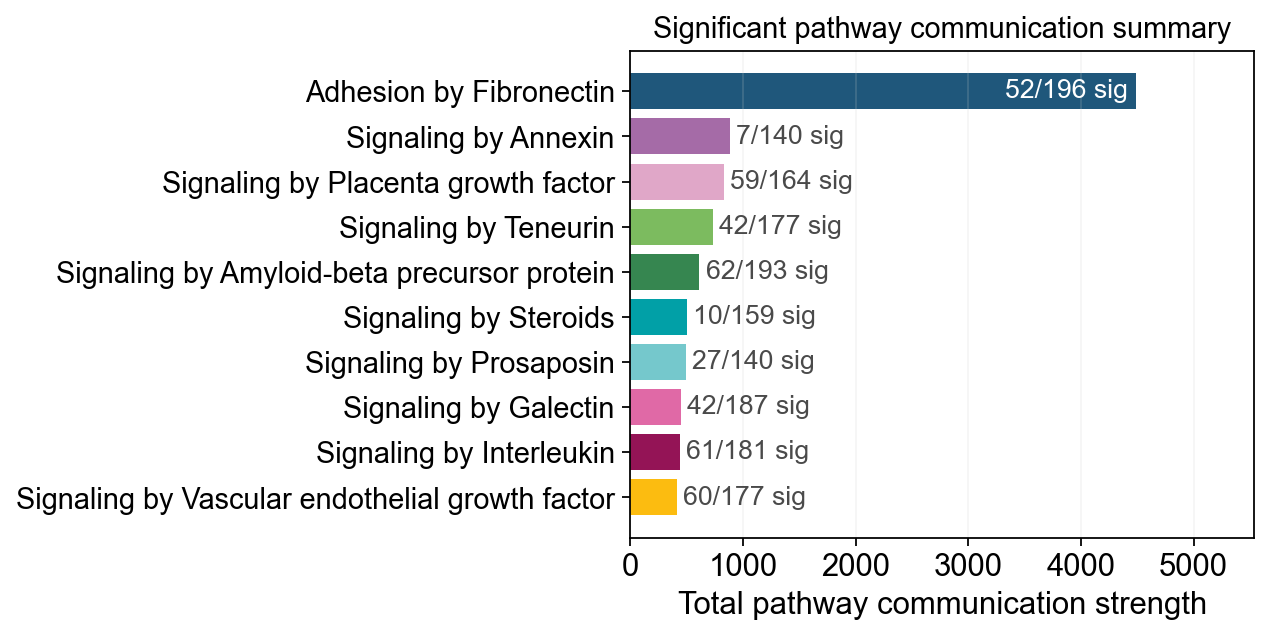

In [30]:
fig, ax = ov.pl.ccc_stat_plot(
    adata_plot,
    plot_type='pathway_summary',
    top_n=10,
    figsize=(5, 4),
    verbose=True,
    show=False,
)

   - Found 13 info columns and 196 cell type pairs
   - Found 121 pathway classifications


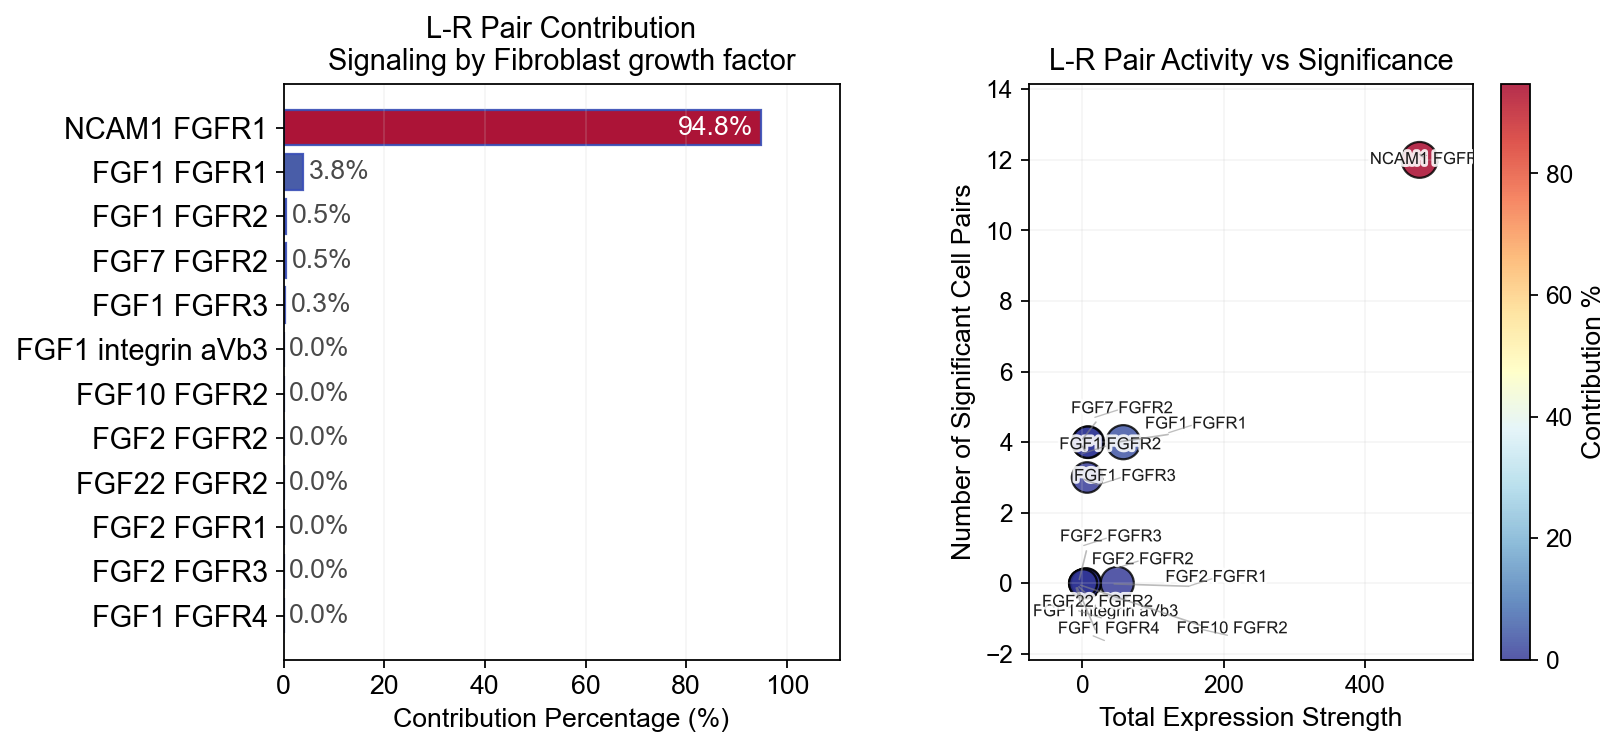

In [31]:
fig, ax = ov.pl.ccc_stat_plot(
    adata_plot,
    plot_type='lr_contribution',
    signaling=['Signaling by Fibroblast growth factor'],
    figsize=(10, 5),
    show=False,
)